# Concrete Crack Detection and Localization Using Deep Learning
## Project Proposal - Data Science Workshop

**Submitted by:** _[name 1, ID]_, _[name 2, ID]_, _[name 3, ID]_
**Supervisor:** _[supervisor name]_

**Goal:** given a concrete image patch, predict a binary mask showing exactly where the crack is.

`RGB patch -> segmentation method -> crack mask`

This proposal presents preliminary results for each main stage of the project. The experiments will be expanded in the final report after receiving feedback.

---
## 1. Problem and goal

We solve **semantic segmentation**: every pixel is predicted as either background (`0`) or crack (`1`).

A crack-free patch therefore has an empty mask; we do not need a separate crack/no-crack classifier.

Our main question is: **can we localize cracks accurately enough to beat simple image-processing baselines?**
We measure success mainly with **Dice** and **IoU**, which compare the predicted mask with the human annotation.

---
## 2. Why segmentation?

A yes/no classifier only tells us that a crack exists. A segmentation mask also tells us **where it is** and gives a basis for measuring its area, width and change over time.

That makes segmentation more useful for inspection: large image collections can be screened automatically and suspicious regions can be shown directly to an engineer.

---
## 3. Data

We use the **Concrete Crack Segmentation Dataset** by Ozgenel (2019), Mendeley Data V1, CC BY 4.0.

The dataset contains **458 concrete photographs and 458 manually annotated masks** in `rgb/` and `BW/`.

The commonly used 40,000-image crack dataset contains classification labels but not masks, so it cannot train our pixel-level segmentation task.

---
## 4. Setup

The notebook uses all 458 source images for cheap quality-control steps and the train/validation/test split.

The more expensive patch-level analysis and preliminary models use a smaller **train + validation subset** controlled by `PROPOSAL_SOURCE_IMAGE_COUNT`. This keeps the proposal practical to rerun while still demonstrating every main stage.

**Order of the analysis:** check image-mask pairs -> split source images -> crop patches -> explore the patches -> compare baseline methods -> train U-Net -> inspect errors.

In [1]:
import copy, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm      # progress bars

from skimage.feature import graycomatrix, graycoprops, hessian_matrix, hessian_matrix_eigvals
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import cv2
import imagehash
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps

import torch                      # imported here to avoid the OpenMP conflict described above
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42  # reproducible random operations
PATCH_SIZE_PIXELS = 256  # patch side at native resolution
MASK_BINARIZATION_THRESHOLD = 127  # threshold used to clean JPEG mask artifacts
MINIMUM_CRACK_PIXELS_PER_PATCH = 50  # fewer pixels than this counts as background
PERCEPTUAL_HASH_DISTANCE_THRESHOLD = 8  # near-duplicate Hamming distance
DATA_SPLIT_FRACTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}
PROPOSAL_SOURCE_IMAGE_COUNT = 60  # source images used for expensive proposal steps
NUMBER_OF_TRAINING_EPOCHS = 15
TRAINING_BATCH_SIZE = 16  # fits the 6 GB GPU at 256x256 with mixed precision

OUTPUT_DIRECTORY = Path("outputs")
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
COMPUTATION_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})
print(f"torch {torch.__version__} | device: {COMPUTATION_DEVICE}")


torch 2.13.0+cu126 | device: cuda


In [2]:
def find_concrete_crack_dataset_directory(search_directory=Path(".")):
    """Find a directory that contains both the rgb/ and BW/ dataset folders."""
    for candidate_directory in sorted(search_directory.rglob("*")):
        if not candidate_directory.is_dir():
            continue
        if (candidate_directory / "rgb").is_dir() and (candidate_directory / "BW").is_dir():
            return candidate_directory
    raise FileNotFoundError(
        "Download the dataset from https://doi.org/10.17632/jwsn7tfbrp.1 and extract it under data/"
    )


def load_oriented_rgb_image(image_file_path):
    """Load an RGB photograph after applying the EXIF orientation."""
    with Image.open(image_file_path) as opened_image:
        corrected_image = ImageOps.exif_transpose(opened_image).convert("RGB")
        return np.asarray(corrected_image)


def load_and_binarize_crack_mask(
    mask_file_path,
    binarization_threshold=MASK_BINARIZATION_THRESHOLD,
):
    """Load an annotation mask and convert it to True=crack, False=background."""
    with Image.open(mask_file_path) as opened_mask:
        grayscale_mask = np.asarray(opened_mask.convert("L"))
    return grayscale_mask > binarization_threshold


def load_downscaled_grayscale_image(
    image_file_path,
    downscale_factor=8,
    apply_exif_orientation=True,
):
    """Load a smaller grayscale copy for quick quality-control calculations."""
    opened_image = Image.open(image_file_path)
    opened_image.draft(
        "L",
        (
            opened_image.size[0] // downscale_factor,
            opened_image.size[1] // downscale_factor,
        ),
    )
    if apply_exif_orientation:
        opened_image = ImageOps.exif_transpose(opened_image)
    return np.asarray(opened_image.convert("L"))


DATASET_DIRECTORY = find_concrete_crack_dataset_directory()
print(
    f"{DATASET_DIRECTORY.as_posix()}: "
    f"{len(list((DATASET_DIRECTORY/'rgb').iterdir()))} images, "
    f"{len(list((DATASET_DIRECTORY/'BW').iterdir()))} masks"
)


data/concrete_crack_segmentation: 458 images, 458 masks


---
## 5. What is one data point?

| Level | One item | Role |
|---|---|---|
| Source image | one photograph + its mask | unit used for train/validation/test splitting |
| Patch | one **256 x 256** crop | one sample given to the models |
| Pixel | one position inside a patch | binary target: background or crack |

We crop image and mask using the same coordinates. The patch table stores paths, crop coordinates, crack statistics and a few simple appearance descriptors; it does **not** store thousands of cropped JPEG files.

---
## 6. Cleaning and quality control

Before modelling, we must make sure every RGB photograph is paired with the correct mask and that both are spatially aligned.

We pair files by **filename stem**, not by directory order, because extensions use different capitalization and image IDs are not consecutive.

In [3]:
EXIF_ORIENTATION_TAG = 274

rgb_image_path_by_filename_stem = {
    image_file_path.stem: image_file_path
    for image_file_path in (DATASET_DIRECTORY / "rgb").iterdir()
    if image_file_path.is_file()
}
mask_path_by_filename_stem = {
    mask_file_path.stem: mask_file_path
    for mask_file_path in (DATASET_DIRECTORY / "BW").iterdir()
    if mask_file_path.is_file()
}
paired_filename_stems = sorted(
    set(rgb_image_path_by_filename_stem) & set(mask_path_by_filename_stem),
    key=lambda filename_stem: (len(filename_stem), filename_stem),
)

source_image_records = []
for filename_stem in tqdm(
    paired_filename_stems,
    desc="pairing RGB images and masks",
):
    rgb_image_file_path = rgb_image_path_by_filename_stem[filename_stem]
    mask_file_path = mask_path_by_filename_stem[filename_stem]

    with Image.open(rgb_image_file_path) as opened_rgb_image:
        stored_image_size = opened_rgb_image.size
        exif_orientation_value = opened_rgb_image.getexif().get(
            EXIF_ORIENTATION_TAG
        )
        corrected_image_size = ImageOps.exif_transpose(
            opened_rgb_image
        ).size

    with Image.open(mask_file_path) as opened_mask:
        annotation_mask_size = opened_mask.size

    source_image_records.append({
        "image_id": filename_stem,
        "rgb_path": rgb_image_file_path.as_posix(),
        "mask_path": mask_file_path.as_posix(),
        "exif_orientation": exif_orientation_value,
        "fixed_w": corrected_image_size[0],
        "fixed_h": corrected_image_size[1],
        "match_raw": stored_image_size == annotation_mask_size,
        "match_fixed": corrected_image_size == annotation_mask_size,
    })

source_image_table = pd.DataFrame(source_image_records)

orphan_rgb_image_count = len(
    set(rgb_image_path_by_filename_stem) - set(mask_path_by_filename_stem)
)
orphan_mask_count = len(
    set(mask_path_by_filename_stem) - set(rgb_image_path_by_filename_stem)
)

print(
    f"pairs {len(source_image_table)} | "
    f"orphan images {orphan_rgb_image_count} | "
    f"orphan masks {orphan_mask_count}"
)
print(
    "EXIF orientation:",
    source_image_table.exif_orientation.value_counts(dropna=False).to_dict(),
)
print(
    "dimensions match BEFORE exif_transpose: "
    f"{source_image_table.match_raw.sum()}/{len(source_image_table)}"
)
print(
    "dimensions match AFTER exif_transpose: "
    f"{source_image_table.match_fixed.sum()}/{len(source_image_table)}"
)


pairing RGB images and masks:   0%|          | 0/458 [00:00<?, ?it/s]

pairs 458 | orphan images 0 | orphan masks 0
EXIF orientation: {nan: 257, 6.0: 179, 3.0: 15, 1.0: 7}
dimensions match BEFORE exif_transpose: 279/458
dimensions match AFTER exif_transpose: 458/458


**Finding 1 - EXIF orientation matters.**

Some photographs are stored with an EXIF rotation flag while the masks are already saved in their final orientation. A raw width/height check therefore misses real alignment problems.

After applying `ImageOps.exif_transpose`, all 458 image-mask pairs have matching dimensions. We also verify the alignment from image content, not only from shape.

In [4]:
def calculate_mask_alignment_score(grayscale_image, binary_crack_mask):
    """Mean darkness inside the mask minus outside. Clearly positive = aligned."""
    if binary_crack_mask.sum() == 0 or binary_crack_mask.all():
        return np.nan
    pixel_darkness = 255.0 - grayscale_image.astype(np.float32)
    return float(pixel_darkness[binary_crack_mask].mean() - pixel_darkness[~binary_crack_mask].mean())


corrected_alignment_scores, rotated_alignment_scores, uncorrected_alignment_scores = [], [], []
for source_image_row in tqdm(source_image_table.itertuples(), total=len(source_image_table),
                      desc="checking mask alignment"):
    downscaled_binary_mask = (load_downscaled_grayscale_image(source_image_row.mask_path, apply_exif_orientation=False)
                  > MASK_BINARIZATION_THRESHOLD)
    corrected_grayscale_image = load_downscaled_grayscale_image(source_image_row.rgb_path, apply_exif_orientation=True)
    uncorrected_grayscale_image = load_downscaled_grayscale_image(source_image_row.rgb_path, apply_exif_orientation=False)
    common_height = min(corrected_grayscale_image.shape[0], downscaled_binary_mask.shape[0])
    common_width = min(corrected_grayscale_image.shape[1], downscaled_binary_mask.shape[1])
    grayscale_image_crop = corrected_grayscale_image[:common_height, :common_width]
    binary_mask_crop = downscaled_binary_mask[:common_height, :common_width]
    corrected_alignment_scores.append(calculate_mask_alignment_score(grayscale_image_crop, binary_mask_crop))
    rotated_alignment_scores.append(calculate_mask_alignment_score(grayscale_image_crop, binary_mask_crop[::-1, ::-1]))
    uncorrected_alignment_scores.append(
        calculate_mask_alignment_score(uncorrected_grayscale_image, downscaled_binary_mask)
        if uncorrected_grayscale_image.shape == downscaled_binary_mask.shape else np.nan)
source_image_table["align_fixed"] = corrected_alignment_scores
source_image_table["align_unfixed"] = uncorrected_alignment_scores

number_of_correctly_aligned_images = int((np.array(corrected_alignment_scores) > np.array(rotated_alignment_scores)).sum())
print(f"correct orientation beats 180-rotated on {number_of_correctly_aligned_images}/{len(source_image_table)} images")
print(f"mean score: correct {np.nanmean(corrected_alignment_scores):.1f} vs "
      f"rotated {np.nanmean(rotated_alignment_scores):.1f}")
images_with_180_degree_rotation = source_image_table[source_image_table.exif_orientation == 3]
print(f"\nthe {len(images_with_180_degree_rotation)} 'rotate 180' images, invisible to a shape check:")
print(f"  dimensions matched without the fix "
      f"{images_with_180_degree_rotation.match_raw.sum()}/{len(images_with_180_degree_rotation)} | "
      f"alignment WITH fix {images_with_180_degree_rotation.align_fixed.mean():.1f}, "
      f"WITHOUT {images_with_180_degree_rotation.align_unfixed.mean():.1f}")

checking mask alignment:   0%|          | 0/458 [00:00<?, ?it/s]

correct orientation beats 180-rotated on 458/458 images
mean score: correct 68.1 vs rotated 4.9

the 15 'rotate 180' images, invisible to a shape check:
  dimensions matched without the fix 15/15 | alignment WITH fix 70.5, WITHOUT 6.0


The content check confirms that the corrected orientation matches the masks far better than a 180-degree-rotated alternative.

This is an important data-cleaning result: **a pair can have identical dimensions and still be misaligned**. From this point onward every RGB image is loaded through `load_oriented_rgb_image()`.

checking mask values:   0%|          | 0/458 [00:00<?, ?it/s]

,pixel type,percent
0,black (background),98.376%
1,gray (JPEG artifacts),0.519%
2,white (crack),1.104%


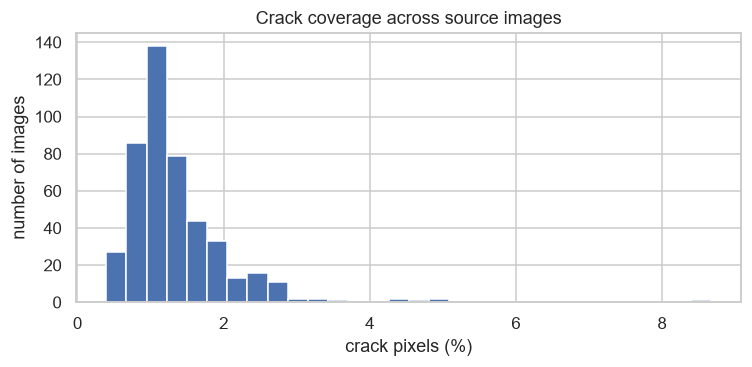

Mean crack coverage: 1.36% | empty source masks: 0


In [5]:
mask_pixel_value_histogram = np.zeros(256, dtype=np.int64)
crack_pixel_count_per_source_image = []

for mask_file_path in tqdm(source_image_table.mask_path, desc="checking mask values"):
    with Image.open(mask_file_path) as opened_mask:
        grayscale_mask_values = np.asarray(opened_mask.convert("L"))
    mask_pixel_value_histogram += np.bincount(
        grayscale_mask_values.ravel(), minlength=256
    )
    crack_pixel_count_per_source_image.append(
        int((grayscale_mask_values > MASK_BINARIZATION_THRESHOLD).sum())
    )

source_image_table["crack_pixels"] = crack_pixel_count_per_source_image
source_image_table["crack_ratio"] = (
    source_image_table["crack_pixels"]
    / (source_image_table.fixed_w * source_image_table.fixed_h)
)

total_mask_pixel_count = mask_pixel_value_histogram.sum()
mask_pixel_value_summary = pd.DataFrame({
    "pixel type": ["black (background)", "gray (JPEG artifacts)", "white (crack)"],
    "percent": [
        100 * mask_pixel_value_histogram[0] / total_mask_pixel_count,
        100 * mask_pixel_value_histogram[1:255].sum() / total_mask_pixel_count,
        100 * mask_pixel_value_histogram[255] / total_mask_pixel_count,
    ],
})

display(mask_pixel_value_summary.style.format({"percent": "{:.3f}%"}))

crack_coverage_figure, crack_coverage_axis = plt.subplots(figsize=(7, 3.5))
crack_coverage_axis.hist(100 * source_image_table.crack_ratio, bins=30)
crack_coverage_axis.set_title("Crack coverage across source images")
crack_coverage_axis.set_xlabel("crack pixels (%)")
crack_coverage_axis.set_ylabel("number of images")
plt.show()

print(
    f"Mean crack coverage: {100 * source_image_table.crack_ratio.mean():.2f}% | "
    f"empty source masks: {(source_image_table['crack_pixels'] == 0).sum()}"
)


**Finding 2 - the masks are not perfectly binary.**

JPEG compression creates intermediate gray values around crack boundaries. We therefore convert every mask to grayscale and apply one fixed threshold (`127`) to obtain a clean binary target.

The masks also show strong pixel imbalance: only a small fraction of pixels belong to cracks. This is why ordinary pixel accuracy will later be misleading.

---
## 7. Split the source images before cropping

Patches cut from the same photograph are highly related, so they must never be divided between training and evaluation.

We first group near-duplicate source photographs with a perceptual hash, then assign whole groups to **70% train, 15% validation and 15% test** while keeping crack coverage similar.

The test split is frozen here and is not used again in this proposal.

In [6]:
def group_near_duplicate_source_images(source_image_paths, maximum_hamming_distance):
    """Group source images whose perceptual hashes are very similar."""
    perceptual_hash_bits = np.array([
        imagehash.phash(
            Image.fromarray(load_downscaled_grayscale_image(source_image_path))
        ).hash.ravel()
        for source_image_path in tqdm(source_image_paths, desc="perceptual hashing")
    ]).astype(np.int8)

    pairwise_hamming_distances = (
        perceptual_hash_bits[:, None, :] != perceptual_hash_bits[None, :, :]
    ).sum(-1)

    parent_image_index = list(range(len(pairwise_hamming_distances)))

    def find_duplicate_group_root(image_index):
        while parent_image_index[image_index] != image_index:
            parent_image_index[image_index] = parent_image_index[
                parent_image_index[image_index]
            ]
            image_index = parent_image_index[image_index]
        return image_index

    near_duplicate_pairs = zip(*np.where(
        np.triu(
            pairwise_hamming_distances <= maximum_hamming_distance,
            k=1,
        )
    ))

    for first_image_index, second_image_index in near_duplicate_pairs:
        first_group_root = find_duplicate_group_root(int(first_image_index))
        second_group_root = find_duplicate_group_root(int(second_image_index))
        if first_group_root != second_group_root:
            parent_image_index[second_group_root] = first_group_root

    duplicate_group_roots = [
        find_duplicate_group_root(image_index)
        for image_index in range(len(pairwise_hamming_distances))
    ]
    duplicate_group_id_by_root = {
        group_root: duplicate_group_id
        for duplicate_group_id, group_root in enumerate(
            sorted(set(duplicate_group_roots))
        )
    }
    return np.array([
        duplicate_group_id_by_root[group_root]
        for group_root in duplicate_group_roots
    ])


def assign_duplicate_groups_to_data_splits(
    source_image_dataframe,
    split_fractions,
    random_seed=RANDOM_SEED,
):
    """Assign whole duplicate groups while keeping crack coverage similar across splits."""
    random_generator = np.random.default_rng(random_seed)
    assigned_image_count_by_split = {
        split_name: 0 for split_name in split_fractions
    }
    image_count_by_duplicate_group = source_image_dataframe.groupby("dup_group").size()
    stratum_by_duplicate_group = (
        source_image_dataframe.groupby("dup_group").stratum.first()
    )
    split_name_by_duplicate_group = {}

    for crack_ratio_stratum in sorted(source_image_dataframe.stratum.unique()):
        duplicate_groups_in_stratum = stratum_by_duplicate_group[
            stratum_by_duplicate_group == crack_ratio_stratum
        ].index.values

        for duplicate_group_id in random_generator.permutation(
            duplicate_groups_in_stratum
        ):
            number_of_images_already_assigned = max(
                sum(assigned_image_count_by_split.values()), 1
            )
            selected_split_name = max(
                split_fractions,
                key=lambda candidate_split_name: (
                    split_fractions[candidate_split_name]
                    - assigned_image_count_by_split[candidate_split_name]
                    / number_of_images_already_assigned
                ),
            )
            split_name_by_duplicate_group[duplicate_group_id] = selected_split_name
            assigned_image_count_by_split[selected_split_name] += int(
                image_count_by_duplicate_group[duplicate_group_id]
            )

    return split_name_by_duplicate_group


source_image_table["dup_group"] = group_near_duplicate_source_images(
    source_image_table.rgb_path,
    PERCEPTUAL_HASH_DISTANCE_THRESHOLD,
)
source_image_table["stratum"] = pd.qcut(
    source_image_table.crack_ratio,
    4,
    labels=False,
)
source_image_table["split"] = source_image_table.dup_group.map(
    assign_duplicate_groups_to_data_splits(
        source_image_table,
        DATA_SPLIT_FRACTIONS,
    )
)

data_split_summary = (
    source_image_table.groupby("split")
    .agg(
        images=("image_id", "size"),
        mean_crack_pct=(
            "crack_ratio",
            lambda crack_ratios: 100 * crack_ratios.mean(),
        ),
    )
    .reindex(["train", "val", "test"])
)
display(data_split_summary.style.format({"mean_crack_pct": "{:.2f}%"}))

image_ids_by_split = {
    split_name: set(
        source_image_table.loc[
            source_image_table.split == split_name,
            "image_id",
        ]
    )
    for split_name in DATA_SPLIT_FRACTIONS
}
duplicate_groups_by_split = {
    split_name: set(
        source_image_table.loc[
            source_image_table.split == split_name,
            "dup_group",
        ]
    )
    for split_name in DATA_SPLIT_FRACTIONS
}

for first_split_name in image_ids_by_split:
    for second_split_name in image_ids_by_split:
        if first_split_name < second_split_name:
            assert not (
                image_ids_by_split[first_split_name]
                & image_ids_by_split[second_split_name]
            ), f"image leak {first_split_name}/{second_split_name}"
            assert not (
                duplicate_groups_by_split[first_split_name]
                & duplicate_groups_by_split[second_split_name]
            ), f"duplicate-group leak {first_split_name}/{second_split_name}"

print("PASS: image ids and duplicate groups are disjoint across splits")
source_image_table.to_csv(OUTPUT_DIRECTORY / "split.csv", index=False)


perceptual hashing:   0%|          | 0/458 [00:00<?, ?it/s]

,images,mean_crack_pct
split,,
train,320,1.38%
val,69,1.26%
test,69,1.34%


PASS: image ids and duplicate groups are disjoint across splits


The table checks that the three splits contain similar average crack coverage, while the assertions verify that neither image IDs nor near-duplicate groups cross split boundaries.

The assignment is saved to `outputs/split.csv` so later experiments use the same split. **All remaining proposal analysis uses only train and validation.**

---
## 8. Create 256 x 256 patches

The original photographs are large, while the models need fixed-size inputs. We therefore **crop** non-overlapping `256 x 256` patches instead of resizing the full image.

Cropping preserves thin cracks that could disappear during aggressive downscaling. Image and mask always use the same crop coordinates.

For the proposal we sample a small number of **train and validation source images only**; the held-out test images remain untouched.

creating patch table:   0%|          | 0/60 [00:00<?, ?it/s]

,patches,crack_containing_patches,crack_patch_pct,empty_patches
split,,,,
train,8028,1400,17.4%,6628
val,1758,274,15.6%,1484


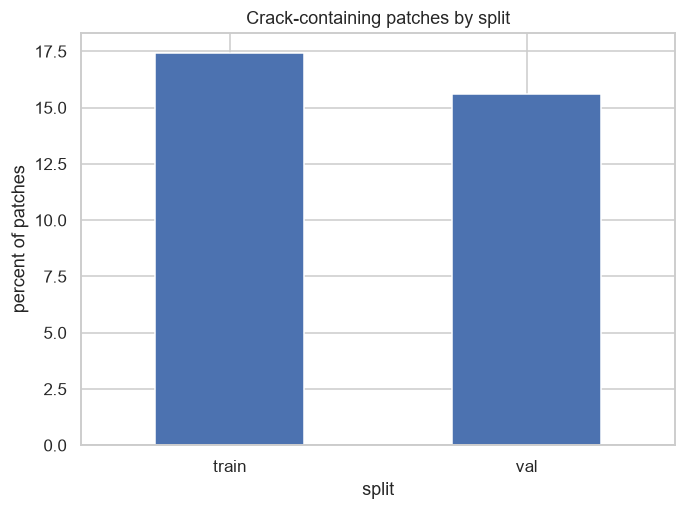

9,786 patches from 60 source images in 30s | 82.4% completely empty


In [7]:
def calculate_patch_appearance_descriptors(rgb_image_patch):
    """Calculate simple patch-level descriptors used only for exploratory analysis."""
    grayscale_patch = cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    grayscale_float_values = grayscale_patch.astype(np.float32)
    fifth_percentile, ninety_fifth_percentile = np.percentile(grayscale_float_values, [5, 95])
    quantized_grayscale_patch = (cv2.resize(grayscale_patch, (64, 64), interpolation=cv2.INTER_AREA)
                 // 32).astype(np.uint8)
    gray_level_cooccurrence_matrix = graycomatrix(quantized_grayscale_patch, [1], [0, np.pi / 2], levels=8,
                        symmetric=True, normed=True)
    return dict(gray_mean=float(grayscale_float_values.mean()), gray_std=float(grayscale_float_values.std()),
                dyn_range=float(ninety_fifth_percentile - fifth_percentile),
                edge_density=float((cv2.Canny(grayscale_patch, 50, 150) > 0).mean()),
                lap_var=float(cv2.Laplacian(grayscale_patch, cv2.CV_32F).var()),
                sat_mean=float(cv2.cvtColor(rgb_image_patch,
                                            cv2.COLOR_RGB2HSV)[:, :, 1].mean()),
                glcm_contrast=float(graycoprops(gray_level_cooccurrence_matrix, "contrast").mean()))


def create_patch_records_for_source_image(source_image_row, patch_size=PATCH_SIZE_PIXELS):
    """One record per grid patch of a source image, with its crack statistics."""
    full_rgb_image = load_oriented_rgb_image(source_image_row.rgb_path)
    full_binary_mask = load_and_binarize_crack_mask(source_image_row.mask_path)
    assert full_rgb_image.shape[:2] == full_binary_mask.shape, f"{source_image_row.image_id}: shape mismatch"
    image_height, image_width = full_binary_mask.shape
    patch_top_left_coordinates = [(patch_top_coordinate, patch_left_coordinate) for patch_top_coordinate in range(0, image_height - patch_size + 1, patch_size)
               for patch_left_coordinate in range(0, image_width - patch_size + 1, patch_size)]
    patch_records = []
    for patch_index, (patch_top_coordinate, patch_left_coordinate) in enumerate(patch_top_left_coordinates):
        patch_row_slice = slice(
            patch_top_coordinate, patch_top_coordinate + patch_size
        )
        patch_column_slice = slice(
            patch_left_coordinate, patch_left_coordinate + patch_size
        )
        binary_mask_patch = full_binary_mask[patch_row_slice, patch_column_slice]                     # identical coordinates
        number_of_crack_pixels = int(binary_mask_patch.sum())
        patch_record = dict(image_id=source_image_row.image_id, split=source_image_row.split,
                      patch_id=patch_index, y0=patch_top_coordinate, x0=patch_left_coordinate, size=patch_size,
                      crack_pixels=number_of_crack_pixels,
                      crack_ratio=number_of_crack_pixels / patch_size ** 2,
                      has_crack=number_of_crack_pixels >= MINIMUM_CRACK_PIXELS_PER_PATCH)
        patch_record.update(calculate_patch_appearance_descriptors(full_rgb_image[patch_row_slice, patch_column_slice]))
        patch_records.append(patch_record)
    return patch_records


subset_sampling_random_generator = np.random.default_rng(RANDOM_SEED)

# Proposal subset comes only from train + validation.
development_split_fraction = DATA_SPLIT_FRACTIONS["train"] + DATA_SPLIT_FRACTIONS["val"]
number_of_training_subset_images = round(
    PROPOSAL_SOURCE_IMAGE_COUNT * DATA_SPLIT_FRACTIONS["train"] / development_split_fraction
)
proposal_source_image_counts_by_split = {
    "train": number_of_training_subset_images,
    "val": PROPOSAL_SOURCE_IMAGE_COUNT - number_of_training_subset_images,
}

proposal_source_image_ids = []
for split_name, number_of_source_images_to_sample in proposal_source_image_counts_by_split.items():
    source_image_ids_in_split = source_image_table.loc[
        source_image_table.split == split_name, "image_id"
    ].values
    proposal_source_image_ids.extend(
        subset_sampling_random_generator.choice(
            source_image_ids_in_split,
            size=min(number_of_source_images_to_sample, len(source_image_ids_in_split)),
            replace=False,
        )
    )

proposal_source_image_table = source_image_table[source_image_table.image_id.isin(proposal_source_image_ids)]

calculation_start_time = time.time()
patch_metadata_table = pd.DataFrame([
    patch_record
    for source_image_row in tqdm(
        proposal_source_image_table.itertuples(),
        total=len(proposal_source_image_table),
        desc="creating patch table",
    )
    for patch_record in create_patch_records_for_source_image(source_image_row)
])
patch_metadata_table.to_parquet(OUTPUT_DIRECTORY / "patch_index.parquet", index=False)

patch_split_summary = (
    patch_metadata_table.groupby("split")
    .agg(
        patches=("patch_id", "size"),
        crack_containing_patches=("has_crack", "sum"),
        crack_patch_pct=("has_crack", lambda crack_flags: 100 * crack_flags.mean()),
    )
    .reindex(["train", "val"])
)
patch_split_summary["empty_patches"] = (
    patch_split_summary["patches"] - patch_split_summary["crack_containing_patches"]
)

display(
    patch_split_summary.style.format({"crack_patch_pct": "{:.1f}%"})
)

patch_split_summary["crack_patch_pct"].plot.bar(
    title="Crack-containing patches by split",
    ylabel="percent of patches",
    rot=0,
)
plt.show()

print(
    f"{len(patch_metadata_table):,} patches from {len(proposal_source_image_table)} source images "
    f"in {time.time()-calculation_start_time:.0f}s | "
    f"{100*(patch_metadata_table.crack_pixels == 0).mean():.1f}% completely empty"
)


Most cropped patches contain no crack at all. That is expected: every **source photograph** contains a crack, but the crack occupies only a small part of the large image.

This imbalance affects training and evaluation:

- **Training:** keep all crack patches and sample a similar number of empty patches.
- **Validation:** keep the complete grid so the score reflects the real distribution.

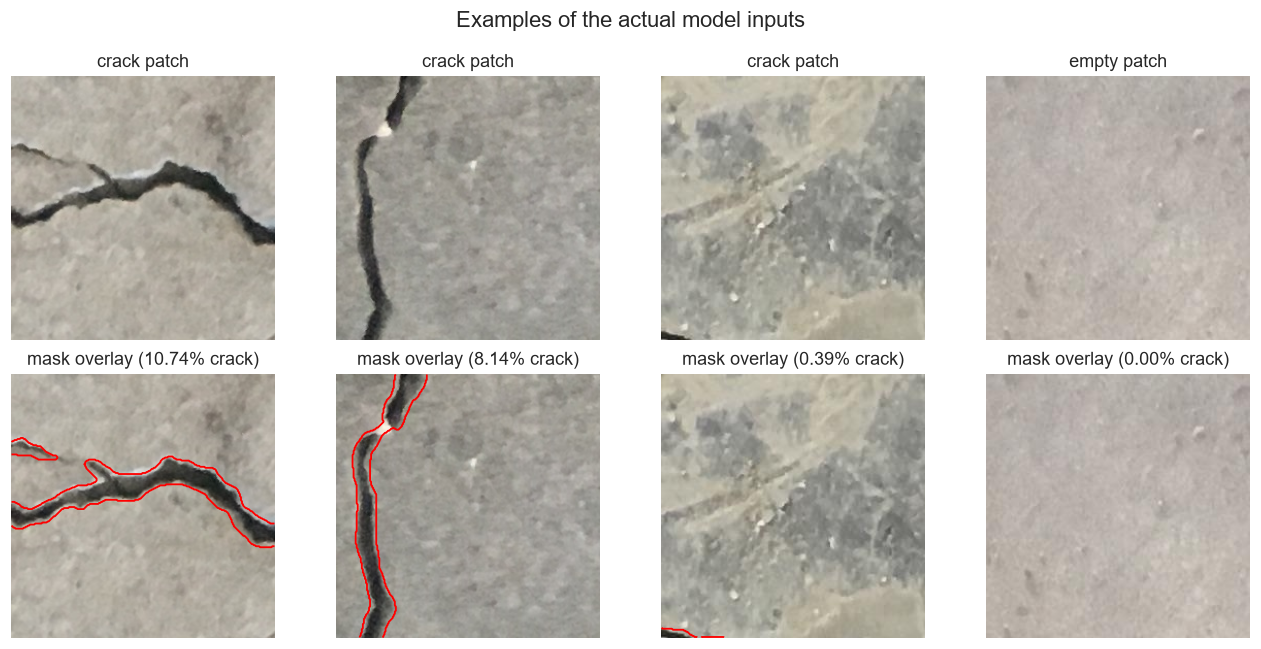

In [8]:
source_paths_by_image_id = source_image_table.set_index("image_id")[["rgb_path", "mask_path"]]

crack_patch_examples = patch_metadata_table[patch_metadata_table.has_crack].sample(3, random_state=RANDOM_SEED)
empty_patch_example = patch_metadata_table[~patch_metadata_table.has_crack].sample(1, random_state=RANDOM_SEED)
example_patch_rows = pd.concat([crack_patch_examples, empty_patch_example]).reset_index(drop=True)

patch_example_figure, patch_example_axes = plt.subplots(2, 4, figsize=(12, 6))

for example_column_index, patch_metadata_row in enumerate(example_patch_rows.itertuples()):
    source_image_paths = source_paths_by_image_id.loc[patch_metadata_row.image_id]
    patch_row_slice = slice(patch_metadata_row.y0, patch_metadata_row.y0 + patch_metadata_row.size)
    patch_column_slice = slice(patch_metadata_row.x0, patch_metadata_row.x0 + patch_metadata_row.size)

    rgb_image_patch = load_oriented_rgb_image(source_image_paths.rgb_path)[patch_row_slice, patch_column_slice]
    binary_mask_patch = load_and_binarize_crack_mask(source_image_paths.mask_path)[patch_row_slice, patch_column_slice]

    patch_example_axes[0, example_column_index].imshow(rgb_image_patch)
    patch_example_axes[0, example_column_index].set_title(
        "crack patch" if patch_metadata_row.has_crack else "empty patch"
    )

    patch_example_axes[1, example_column_index].imshow(rgb_image_patch)
    if binary_mask_patch.any():
        patch_example_axes[1, example_column_index].contour(
            binary_mask_patch.astype(float), [0.5], colors="red", linewidths=1.2
        )
    patch_example_axes[1, example_column_index].set_title(
        f"mask overlay ({100*patch_metadata_row.crack_ratio:.2f}% crack)"
    )

    patch_example_axes[0, example_column_index].axis("off")
    patch_example_axes[1, example_column_index].axis("off")

patch_example_figure.suptitle("Examples of the actual model inputs")
plt.show()


These examples are the most important visual sanity check: the red annotation should lie on the visible crack, and an empty patch should have no contour.

At this point we know the files are paired correctly, orientation is fixed, masks are binary and the crop coordinates are aligned.

---
## 9. EDA - can simple appearance features explain the cracks?

Before training models, we summarize each **training patch** with a few simple descriptors such as brightness, contrast, edge density and texture.

We use them only to understand the dataset; they are **not inputs to the U-Net**.

Two questions guide this section:

1. Which descriptors are related to crack coverage?
2. Do the patches naturally separate into clear visual groups?

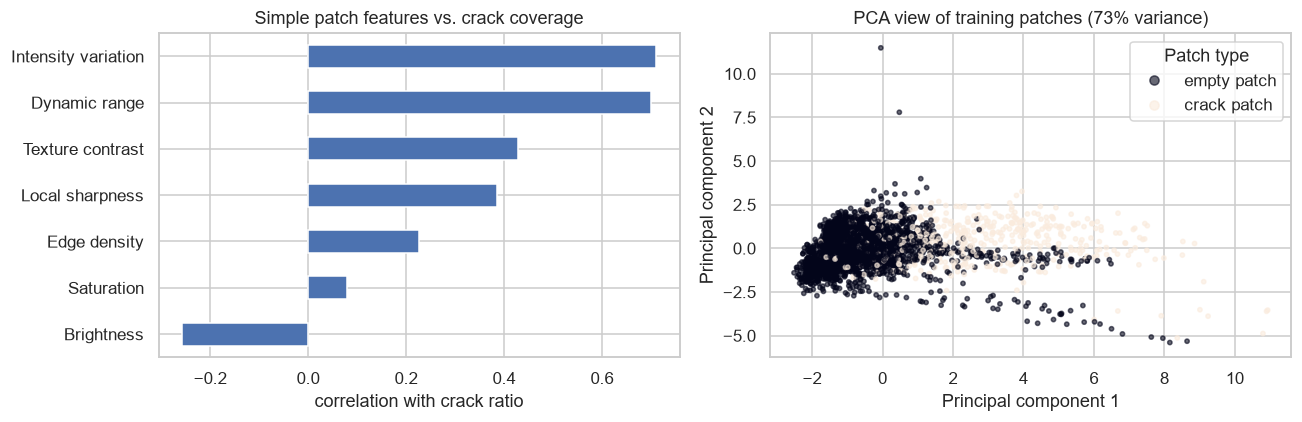

In [9]:
PATCH_DESCRIPTOR_COLUMNS = [
    "gray_mean",
    "gray_std",
    "dyn_range",
    "edge_density",
    "lap_var",
    "sat_mean",
    "glcm_contrast",
]

PATCH_DESCRIPTOR_DISPLAY_NAMES = {
    "gray_mean": "Brightness",
    "gray_std": "Intensity variation",
    "dyn_range": "Dynamic range",
    "edge_density": "Edge density",
    "lap_var": "Local sharpness",
    "sat_mean": "Saturation",
    "glcm_contrast": "Texture contrast",
}

training_patch_metadata_for_eda = patch_metadata_table[
    patch_metadata_table.split == "train"
].copy()
sampled_training_patches_for_eda = training_patch_metadata_for_eda.sample(
    min(3000, len(training_patch_metadata_for_eda)),
    random_state=RANDOM_SEED,
).reset_index(drop=True)

patch_descriptor_standardizer = StandardScaler()
standardized_patch_descriptor_matrix = patch_descriptor_standardizer.fit_transform(
    sampled_training_patches_for_eda[PATCH_DESCRIPTOR_COLUMNS]
)

principal_component_analysis_model = PCA(
    n_components=2,
    random_state=RANDOM_SEED,
)
two_dimensional_pca_coordinates = principal_component_analysis_model.fit_transform(
    standardized_patch_descriptor_matrix
)

descriptor_correlation_with_crack_ratio = (
    training_patch_metadata_for_eda[PATCH_DESCRIPTOR_COLUMNS + ["crack_ratio"]]
    .corr()["crack_ratio"]
    .drop("crack_ratio")
    .sort_values()
)
descriptor_correlation_for_display = descriptor_correlation_with_crack_ratio.rename(
    index=PATCH_DESCRIPTOR_DISPLAY_NAMES
)

eda_figure, eda_axes = plt.subplots(1, 2, figsize=(12, 4))

descriptor_correlation_for_display.plot.barh(ax=eda_axes[0])
eda_axes[0].set_title("Simple patch features vs. crack coverage")
eda_axes[0].set_xlabel("correlation with crack ratio")

pca_scatter_plot = eda_axes[1].scatter(
    two_dimensional_pca_coordinates[:, 0],
    two_dimensional_pca_coordinates[:, 1],
    c=sampled_training_patches_for_eda["has_crack"].astype(int),
    s=8,
    alpha=0.6,
)
eda_axes[1].set_title(
    "PCA view of training patches "
    f"({100 * principal_component_analysis_model.explained_variance_ratio_.sum():.0f}% variance)"
)
eda_axes[1].set_xlabel("Principal component 1")
eda_axes[1].set_ylabel("Principal component 2")

pca_legend_handles, _ = pca_scatter_plot.legend_elements()
eda_axes[1].legend(
    pca_legend_handles,
    ["empty patch", "crack patch"],
    title="Patch type",
)

plt.show()


The simple descriptors contain useful information, but they do not cleanly separate crack and empty patches.

Crack-containing patches tend to have greater **intensity variation, dynamic range and texture**, while brightness is negatively associated with crack coverage. The first two PCA components explain about **73% of the descriptor variance**, yet substantial overlap remains between the two patch types.

This suggests that simple global appearance descriptors alone are unlikely to solve the segmentation problem and motivates models that use local spatial structure.

KMeans:   0%|          | 0/5 [00:00<?, ?it/s]

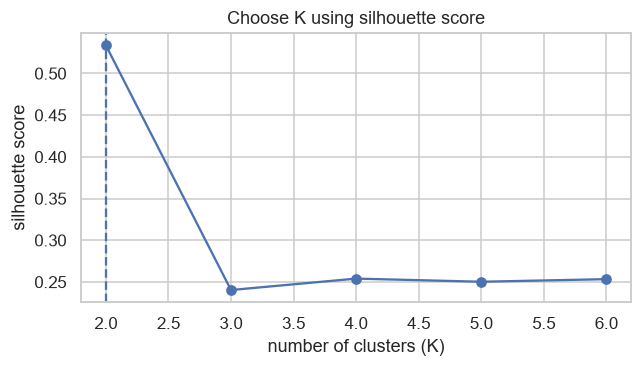

,patches,crack_patch_pct,mean_brightness,mean_texture
cluster,,,,
0,430,68.1%,172.6,0.32
1,2570,8.2%,185.6,0.12


Selected K = 2


In [10]:
silhouette_scores_by_cluster_count = []

for number_of_clusters in tqdm([2, 3, 4, 5, 6], desc="KMeans"):
    cluster_labels = KMeans(
        n_clusters=number_of_clusters,
        n_init=10,
        random_state=RANDOM_SEED,
    ).fit_predict(standardized_patch_descriptor_matrix)
    silhouette_scores_by_cluster_count.append((
        number_of_clusters,
        silhouette_score(standardized_patch_descriptor_matrix, cluster_labels),
    ))

silhouette_score_table = pd.DataFrame(
    silhouette_scores_by_cluster_count,
    columns=["number of clusters", "silhouette score"],
)
selected_number_of_clusters = int(
    silhouette_score_table.loc[
        silhouette_score_table["silhouette score"].idxmax(),
        "number of clusters",
    ]
)

sampled_training_patches_for_eda["cluster"] = KMeans(
    n_clusters=selected_number_of_clusters,
    n_init=10,
    random_state=RANDOM_SEED,
).fit_predict(standardized_patch_descriptor_matrix)

cluster_characteristics_summary = (
    sampled_training_patches_for_eda.groupby("cluster")
    .agg(
        patches=("cluster", "size"),
        crack_patch_pct=("has_crack", lambda crack_flags: 100 * crack_flags.mean()),
        mean_brightness=("gray_mean", "mean"),
        mean_texture=("glcm_contrast", "mean"),
    )
)

silhouette_figure, silhouette_axis = plt.subplots(figsize=(6, 3.5))
silhouette_axis.plot(
    silhouette_score_table["number of clusters"],
    silhouette_score_table["silhouette score"],
    marker="o",
)
silhouette_axis.set_title("Choose K using silhouette score")
silhouette_axis.set_xlabel("number of clusters (K)")
silhouette_axis.set_ylabel("silhouette score")
silhouette_axis.axvline(selected_number_of_clusters, linestyle="--")
plt.show()

display(
    cluster_characteristics_summary.style.format({
        "crack_patch_pct": "{:.1f}%",
        "mean_brightness": "{:.1f}",
        "mean_texture": "{:.2f}",
    })
)

print(f"Selected K = {selected_number_of_clusters}")


K-Means groups patches by **visual appearance**, not by the crack label. The silhouette score chooses the number of clusters rather than selecting it arbitrarily.

We then inspect each cluster to ask a practical question: are some surface conditions brighter, rougher or more likely to contain cracks? In the final project these groups can also be used to compare model performance under different visual conditions.

---
## 10. How do we measure a segmentation?

For every pixel, the prediction can be correct or wrong. From those counts we use four simple metrics:

| Metric | Intuition |
|---|---|
| **Dice** | How strongly do the predicted and true crack regions overlap? |
| **IoU** | Overlap divided by the total area covered by either mask; stricter than Dice |
| **Precision** | Of the pixels predicted as crack, how many were really crack? |
| **Recall** | Of the real crack pixels, how many did we find? |

The two main overlap formulas are:

`Dice = 2TP / (2TP + FP + FN)`
`IoU  = TP / (TP + FP + FN)`

Because crack pixels are rare, **pixel accuracy is not our main metric**. A model can predict only background and still appear highly accurate.

In [11]:
def calculate_pixel_confusion_counts(predicted_mask, ground_truth_mask):
    """Count pixel-level true positives, false positives, false negatives and true negatives."""
    true_positive_count = int(np.count_nonzero(predicted_mask & ground_truth_mask))
    false_positive_count = int(np.count_nonzero(predicted_mask & ~ground_truth_mask))
    false_negative_count = int(np.count_nonzero(~predicted_mask & ground_truth_mask))
    true_negative_count = (
        predicted_mask.size
        - true_positive_count
        - false_positive_count
        - false_negative_count
    )
    return (
        true_positive_count,
        false_positive_count,
        false_negative_count,
        true_negative_count,
    )


def calculate_segmentation_metrics(
    true_positive_count,
    false_positive_count,
    false_negative_count,
):
    """Calculate Dice, IoU, precision and recall from the pixel counts."""
    if (
        true_positive_count
        + false_positive_count
        + false_negative_count
        == 0
    ):
        return dict(dice=1.0, iou=1.0, precision=1.0, recall=1.0)

    dice_score = (
        2 * true_positive_count
        / (
            2 * true_positive_count
            + false_positive_count
            + false_negative_count
        )
    )
    intersection_over_union = (
        true_positive_count
        / (
            true_positive_count
            + false_positive_count
            + false_negative_count
        )
    )
    precision_score = (
        true_positive_count / (true_positive_count + false_positive_count)
        if true_positive_count + false_positive_count
        else 0.0
    )
    recall_score = (
        true_positive_count / (true_positive_count + false_negative_count)
        if true_positive_count + false_negative_count
        else 0.0
    )

    return dict(
        dice=dice_score,
        iou=intersection_over_union,
        precision=precision_score,
        recall=recall_score,
    )


def evaluate_segmentation_predictions(prediction_pairs):
    """Evaluate a sequence of predicted masks against their ground-truth masks."""
    total_true_positive = 0
    total_false_positive = 0
    total_false_negative = 0
    total_true_negative = 0
    per_patch_metric_results = []

    for predicted_mask, ground_truth_mask in prediction_pairs:
        (
            true_positive_count,
            false_positive_count,
            false_negative_count,
            true_negative_count,
        ) = calculate_pixel_confusion_counts(predicted_mask, ground_truth_mask)

        total_true_positive += true_positive_count
        total_false_positive += false_positive_count
        total_false_negative += false_negative_count
        total_true_negative += true_negative_count

        per_patch_metric_results.append(
            calculate_segmentation_metrics(
                true_positive_count,
                false_positive_count,
                false_negative_count,
            )
        )

    micro_metrics = calculate_segmentation_metrics(
        total_true_positive,
        total_false_positive,
        total_false_negative,
    )
    evaluation_summary = {
        f"micro_{metric_name}": metric_value
        for metric_name, metric_value in micro_metrics.items()
    }
    evaluation_summary["macro_dice"] = float(np.mean([
        patch_metrics["dice"]
        for patch_metrics in per_patch_metric_results
    ]))
    evaluation_summary["pixel_accuracy"] = (
        (total_true_positive + total_true_negative)
        / (
            total_true_positive
            + total_false_positive
            + total_false_negative
            + total_true_negative
        )
    )
    return evaluation_summary


def iterate_image_mask_patches_for_split(
    split_name,
    progress_description=None,
):
    """Yield aligned RGB and mask patches while loading each source image only once."""
    patches_for_selected_split = patch_metadata_table[
        patch_metadata_table.split == split_name
    ]

    def generate_image_mask_patch_pairs():
        for source_image_id, source_image_patch_rows in patches_for_selected_split.groupby(
            "image_id"
        ):
            source_image_paths = source_paths_by_image_id.loc[source_image_id]
            full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
            full_binary_mask = load_and_binarize_crack_mask(
                source_image_paths.mask_path
            )

            for patch_metadata_row in source_image_patch_rows.itertuples():
                patch_row_slice = slice(
                    patch_metadata_row.y0,
                    patch_metadata_row.y0 + patch_metadata_row.size,
                )
                patch_column_slice = slice(
                    patch_metadata_row.x0,
                    patch_metadata_row.x0 + patch_metadata_row.size,
                )
                yield (
                    full_rgb_image[patch_row_slice, patch_column_slice],
                    full_binary_mask[patch_row_slice, patch_column_slice],
                )

    return tqdm(
        generate_image_mask_patch_pairs(),
        total=len(patches_for_selected_split),
        desc=progress_description or f"{split_name} patches",
        leave=False,
    )


print("Metric helper functions are ready")


Metric helper functions are ready


---
## 11. Models - from simplest to strongest

All methods below solve the **same task**: produce a binary crack mask.

We compare the methods from the simplest baseline to the deep-learning model:

1. **All background:** a sanity-check baseline.
2. **Otsu:** automatically separates darker and brighter pixels.
3. **Black-hat morphology:** emphasizes thin dark structures before thresholding.
4. **Logistic Regression:** learns a crack probability for each pixel from a small hand-crafted feature set.
5. **U-Net:** learns the useful image features and spatial context directly from RGB patches.

The value of this progression is not the number of models; it is seeing **what extra capability each step adds**.

### 11.1 Classical image-processing baselines

These methods do not learn from examples.

- **A0:** predict background everywhere.
- **Otsu:** choose a brightness threshold automatically from each patch.
- **Black-hat:** first highlight thin dark structures, then threshold them.

They give us a low-complexity reference point before machine learning.

Background:   0%|          | 0/1758 [00:00<?, ?it/s]

Otsu:   0%|          | 0/1758 [00:00<?, ?it/s]

Black-hat:   0%|          | 0/1758 [00:00<?, ?it/s]

,micro_dice,micro_iou,micro_precision,micro_recall,pixel_accuracy
method,,,,,
Background,0.000,0.000,0.000,0.000,0.988
Otsu,0.044,0.023,0.023,0.668,0.643
Black-hat,0.519,0.350,0.892,0.366,0.992


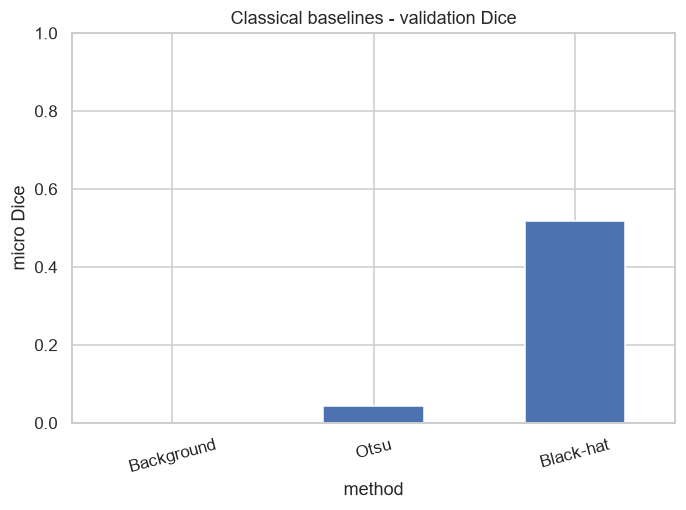

In [12]:
local_contrast_enhancer = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8, 8),
)


def predict_crack_mask_with_otsu(rgb_image_patch):
    """Create a crack mask using Otsu thresholding on inverted grayscale."""
    grayscale_patch = cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    _, otsu_binary_image = cv2.threshold(
        255 - grayscale_patch,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )
    return otsu_binary_image > 0


def predict_crack_mask_with_black_hat(
    rgb_image_patch,
    kernel_size=101,
    intensity_threshold=160,
    minimum_component_area=60,
):
    """Highlight thin dark structures, threshold them and remove tiny components."""
    grayscale_patch = local_contrast_enhancer.apply(
        cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    )
    morphology_structuring_element = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size),
    )
    black_hat_response = cv2.morphologyEx(
        grayscale_patch,
        cv2.MORPH_BLACKHAT,
        morphology_structuring_element,
    )
    thresholded_black_hat = (
        (black_hat_response > intensity_threshold).astype(np.uint8) * 255
    )
    cleaned_binary_image = cv2.morphologyEx(
        thresholded_black_hat,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    )
    (
        number_of_connected_components,
        connected_component_labels,
        connected_component_statistics,
        _,
    ) = cv2.connectedComponentsWithStats(cleaned_binary_image, connectivity=8)

    keep_connected_component = np.zeros(number_of_connected_components, bool)
    keep_connected_component[1:] = (
        connected_component_statistics[1:, cv2.CC_STAT_AREA]
        >= minimum_component_area
    )
    return keep_connected_component[connected_component_labels]


validation_model_results = []
baseline_methods = [
    (
        "Background",
        lambda image_patch: np.zeros(image_patch.shape[:2], bool),
    ),
    ("Otsu", predict_crack_mask_with_otsu),
    ("Black-hat", predict_crack_mask_with_black_hat),
]

for method_name, mask_prediction_function in baseline_methods:
    method_validation_metrics = evaluate_segmentation_predictions(
        (
            mask_prediction_function(rgb_image_patch),
            ground_truth_mask,
        )
        for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
            "val",
            progress_description=method_name,
        )
    )
    method_validation_metrics["method"] = method_name
    validation_model_results.append(method_validation_metrics)

classical_baseline_results = pd.DataFrame(validation_model_results).set_index(
    "method"
)
display(
    classical_baseline_results[
        [
            "micro_dice",
            "micro_iou",
            "micro_precision",
            "micro_recall",
            "pixel_accuracy",
        ]
    ].style.format("{:.3f}")
)

classical_baseline_results["micro_dice"].plot.bar(
    title="Classical baselines - validation Dice",
    ylabel="micro Dice",
    ylim=(0, 1),
    rot=15,
)
plt.show()


#### Takeaway from the classical baselines

**The all-background baseline** shows why pixel accuracy is dangerous: predicting only background can look accurate while finding no crack.

**Otsu** is a useful first attempt, but it must split every image into two groups even when a patch contains no crack.

**Black-hat** is more suitable because it specifically emphasizes thin dark structures and is allowed to return an empty mask after thresholding. It becomes our stronger classical baseline.

### 11.2 Simple learned model - per-pixel Logistic Regression

Now we let a model **learn** the decision rule.

Each pixel becomes one training example described by a small set of local image features: intensity, smoothed intensity, edge strength and ridge-like responses at two scales.

Logistic Regression converts those features into `P(crack)` for each pixel. It is still segmentation, but unlike U-Net the features are designed by us rather than learned automatically.

In [13]:
PIXEL_FEATURE_SCALES = [1, 4]


def calculate_pixel_feature_bank(rgb_image_patch):
    """Calculate seven interpretable pixel features at two spatial scales."""
    grayscale_image = cv2.cvtColor(
        rgb_image_patch,
        cv2.COLOR_RGB2GRAY,
    ).astype(np.float32)

    pixel_feature_channels = [grayscale_image]
    pixel_feature_names = ["grayscale_intensity"]

    for filter_scale_sigma in PIXEL_FEATURE_SCALES:
        smoothed_grayscale_image = cv2.GaussianBlur(
            grayscale_image,
            (0, 0),
            filter_scale_sigma,
        )
        horizontal_gradient = cv2.Sobel(
            smoothed_grayscale_image,
            cv2.CV_32F,
            1,
            0,
            ksize=3,
        )
        vertical_gradient = cv2.Sobel(
            smoothed_grayscale_image,
            cv2.CV_32F,
            0,
            1,
            ksize=3,
        )
        ridge_response, _ = hessian_matrix_eigvals(
            hessian_matrix(
                grayscale_image,
                sigma=filter_scale_sigma,
                order="rc",
                use_gaussian_derivatives=False,
            )
        )
        gradient_magnitude = np.sqrt(
            horizontal_gradient**2 + vertical_gradient**2
        )

        pixel_feature_channels.extend([
            smoothed_grayscale_image,
            gradient_magnitude,
            ridge_response.astype(np.float32),
        ])
        pixel_feature_names.extend([
            f"smoothed_intensity_sigma_{filter_scale_sigma}",
            f"gradient_magnitude_sigma_{filter_scale_sigma}",
            f"ridge_response_sigma_{filter_scale_sigma}",
        ])

    return np.stack(pixel_feature_channels, axis=-1), pixel_feature_names


pixel_sampling_random_generator = np.random.default_rng(RANDOM_SEED)
training_patch_rows = patch_metadata_table[
    patch_metadata_table.split == "train"
]
sampled_training_patch_rows = pd.concat([
    training_patch_rows[training_patch_rows.has_crack].sample(
        120,
        random_state=RANDOM_SEED,
    ),
    training_patch_rows[~training_patch_rows.has_crack].sample(
        120,
        random_state=RANDOM_SEED,
    ),
])

sampled_feature_batches = []
sampled_label_batches = []

for source_image_id, source_image_patch_rows in tqdm(
    sampled_training_patch_rows.groupby("image_id"),
    desc="sampling training pixels",
):
    source_image_paths = source_paths_by_image_id.loc[source_image_id]
    full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
    full_binary_mask = load_and_binarize_crack_mask(source_image_paths.mask_path)

    for patch_metadata_row in source_image_patch_rows.itertuples():
        patch_row_slice = slice(
            patch_metadata_row.y0,
            patch_metadata_row.y0 + patch_metadata_row.size,
        )
        patch_column_slice = slice(
            patch_metadata_row.x0,
            patch_metadata_row.x0 + patch_metadata_row.size,
        )
        pixel_feature_grid, PIXEL_FEATURE_NAMES = calculate_pixel_feature_bank(
            full_rgb_image[patch_row_slice, patch_column_slice]
        )
        patch_pixel_target_labels = full_binary_mask[
            patch_row_slice,
            patch_column_slice,
        ].ravel()
        patch_pixel_feature_matrix = pixel_feature_grid.reshape(
            -1,
            pixel_feature_grid.shape[-1],
        )

        crack_pixel_positions = np.flatnonzero(patch_pixel_target_labels)
        background_pixel_positions = np.flatnonzero(~patch_pixel_target_labels)

        sampled_crack_pixel_positions = (
            pixel_sampling_random_generator.choice(
                crack_pixel_positions,
                min(400, len(crack_pixel_positions)),
                replace=False,
            )
            if len(crack_pixel_positions)
            else np.array([], dtype=int)
        )
        sampled_background_pixel_positions = pixel_sampling_random_generator.choice(
            background_pixel_positions,
            min(
                800 - len(sampled_crack_pixel_positions),
                len(background_pixel_positions),
            ),
            replace=False,
        )
        sampled_pixel_positions = np.concatenate([
            sampled_crack_pixel_positions,
            sampled_background_pixel_positions,
        ])

        sampled_feature_batches.append(
            patch_pixel_feature_matrix[sampled_pixel_positions]
        )
        sampled_label_batches.append(
            patch_pixel_target_labels[sampled_pixel_positions]
        )

sampled_pixel_feature_matrix = np.concatenate(sampled_feature_batches)
sampled_pixel_target_labels = np.concatenate(sampled_label_batches)

pixel_feature_standardizer = StandardScaler().fit(sampled_pixel_feature_matrix)
pixel_logistic_regression_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_SEED,
).fit(
    pixel_feature_standardizer.transform(sampled_pixel_feature_matrix),
    sampled_pixel_target_labels,
)


def predict_logistic_regression_crack_probabilities(rgb_image_patch):
    """Predict a crack probability for every pixel using Logistic Regression."""
    pixel_feature_grid, _ = calculate_pixel_feature_bank(rgb_image_patch)
    patch_height, patch_width, number_of_pixel_features = pixel_feature_grid.shape
    pixel_crack_probabilities = pixel_logistic_regression_model.predict_proba(
        pixel_feature_standardizer.transform(
            pixel_feature_grid.reshape(-1, number_of_pixel_features)
        )
    )[:, 1]
    return pixel_crack_probabilities.reshape(patch_height, patch_width)


logistic_regression_validation_metrics = evaluate_segmentation_predictions(
    (
        predict_logistic_regression_crack_probabilities(rgb_image_patch) > 0.5,
        ground_truth_mask,
    )
    for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
        "val",
        progress_description="Logistic Regression",
    )
)
logistic_regression_validation_metrics["method"] = "Logistic Regression"
validation_model_results.append(logistic_regression_validation_metrics)

logistic_regression_validation_summary = pd.DataFrame([{
    "training pixels": len(sampled_pixel_feature_matrix),
    "features per pixel": sampled_pixel_feature_matrix.shape[1],
    "validation Dice": logistic_regression_validation_metrics["micro_dice"],
    "validation IoU": logistic_regression_validation_metrics["micro_iou"],
}])
display(
    logistic_regression_validation_summary.style.format({
        "training pixels": "{:,.0f}",
        "features per pixel": "{:.0f}",
        "validation Dice": "{:.3f}",
        "validation IoU": "{:.3f}",
    })
)


sampling training pixels:   0%|          | 0/49 [00:00<?, ?it/s]

Logistic Regression:   0%|          | 0/1758 [00:00<?, ?it/s]

,training pixels,features per pixel,validation Dice,validation IoU
0,"192,000",7,0.552,0.381


### 11.3 Deep model - U-Net

U-Net receives the RGB patch directly and outputs one crack probability for every pixel.

`RGB patch -> encoder -> bottleneck -> decoder -> probability mask`

The encoder learns increasingly contextual features. The decoder restores the original resolution, while **skip connections** bring back fine spatial detail needed for thin crack boundaries.

For training we combine two losses:

- **BCE:** asks whether each individual pixel probability is correct.
- **Dice loss:** asks whether the predicted crack region overlaps the true region.

We optimize this loss with **Adam**.

In [14]:
class DoubleConvolutionBlock(nn.Module):
    """Two convolution -> batch normalization -> ReLU steps used at one U-Net level."""

    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.convolution_block = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(True),
            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(True),
        )

    def forward(self, input_tensor):
        return self.convolution_block(input_tensor)


class ConcreteCrackUNet(nn.Module):
    """Four-level U-Net used to predict a crack probability for every pixel."""

    def __init__(self, base_channel_width=16):
        super().__init__()
        feature_channel_widths = [
            base_channel_width,
            base_channel_width * 2,
            base_channel_width * 4,
            base_channel_width * 8,
        ]

        self.encoder_level_1 = DoubleConvolutionBlock(
            3,
            feature_channel_widths[0],
        )
        self.encoder_level_2 = DoubleConvolutionBlock(
            feature_channel_widths[0],
            feature_channel_widths[1],
        )
        self.encoder_level_3 = DoubleConvolutionBlock(
            feature_channel_widths[1],
            feature_channel_widths[2],
        )
        self.bottleneck = DoubleConvolutionBlock(
            feature_channel_widths[2],
            feature_channel_widths[3],
        )

        self.upsample_to_level_3 = nn.ConvTranspose2d(
            feature_channel_widths[3],
            feature_channel_widths[2],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_3 = DoubleConvolutionBlock(
            feature_channel_widths[3],
            feature_channel_widths[2],
        )
        self.upsample_to_level_2 = nn.ConvTranspose2d(
            feature_channel_widths[2],
            feature_channel_widths[1],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_2 = DoubleConvolutionBlock(
            feature_channel_widths[2],
            feature_channel_widths[1],
        )
        self.upsample_to_level_1 = nn.ConvTranspose2d(
            feature_channel_widths[1],
            feature_channel_widths[0],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_1 = DoubleConvolutionBlock(
            feature_channel_widths[1],
            feature_channel_widths[0],
        )

        self.output_probability_layer = nn.Conv2d(
            feature_channel_widths[0],
            1,
            kernel_size=1,
        )
        self.max_pooling_layer = nn.MaxPool2d(2)

    def forward(self, input_tensor):
        encoder_features_level_1 = self.encoder_level_1(input_tensor)
        encoder_features_level_2 = self.encoder_level_2(
            self.max_pooling_layer(encoder_features_level_1)
        )
        encoder_features_level_3 = self.encoder_level_3(
            self.max_pooling_layer(encoder_features_level_2)
        )
        bottleneck_features = self.bottleneck(
            self.max_pooling_layer(encoder_features_level_3)
        )

        decoder_features = self.decoder_level_3(torch.cat([
            self.upsample_to_level_3(bottleneck_features),
            encoder_features_level_3,
        ], dim=1))
        decoder_features = self.decoder_level_2(torch.cat([
            self.upsample_to_level_2(decoder_features),
            encoder_features_level_2,
        ], dim=1))
        decoder_features = self.decoder_level_1(torch.cat([
            self.upsample_to_level_1(decoder_features),
            encoder_features_level_1,
        ], dim=1))

        return self.output_probability_layer(decoder_features)


def calculate_combined_bce_dice_loss(
    model_logits,
    target_mask,
    smoothing_constant=1.0,
):
    """Combine pixel-wise BCE with a Dice overlap loss."""
    crack_probabilities = torch.sigmoid(model_logits)
    dice_overlap_numerator = (
        2 * (crack_probabilities * target_mask).sum((1, 2, 3))
        + smoothing_constant
    )
    dice_overlap_denominator = (
        crack_probabilities.sum((1, 2, 3))
        + target_mask.sum((1, 2, 3))
        + smoothing_constant
    )
    dice_loss_term = 1 - (
        dice_overlap_numerator / dice_overlap_denominator
    ).mean()

    binary_cross_entropy_loss = F.binary_cross_entropy_with_logits(
        model_logits,
        target_mask,
    )
    return binary_cross_entropy_loss + dice_loss_term


#### Prepare the U-Net data

Training is intentionally balanced: we keep all crack-containing training patches and sample a similar number of empty patches.

Validation remains unbalanced and complete because evaluation should reflect the real patch distribution.

In [15]:
def load_patch_arrays_for_split(split_name, balance_training_patches):
    """Load all patch images and masks needed for one data split."""
    random_generator = np.random.default_rng(RANDOM_SEED)
    selected_patch_rows = patch_metadata_table[
        patch_metadata_table.split == split_name
    ]

    if balance_training_patches:
        crack_containing_patches = selected_patch_rows[
            selected_patch_rows.has_crack
        ]
        empty_background_patches = selected_patch_rows[
            ~selected_patch_rows.has_crack
        ]
        sampled_empty_patches = empty_background_patches.sample(
            min(
                len(empty_background_patches),
                len(crack_containing_patches),
            ),
            random_state=RANDOM_SEED,
        )
        selected_patch_rows = pd.concat([
            crack_containing_patches,
            sampled_empty_patches,
        ])

    loaded_patch_images = []
    loaded_patch_masks = []

    for source_image_id, source_image_patch_rows in tqdm(
        selected_patch_rows.groupby("image_id"),
        desc=f"loading {split_name} patches",
    ):
        source_image_paths = source_paths_by_image_id.loc[source_image_id]
        full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
        full_binary_mask = load_and_binarize_crack_mask(
            source_image_paths.mask_path
        )

        for patch_metadata_row in source_image_patch_rows.itertuples():
            patch_row_slice = slice(
                patch_metadata_row.y0,
                patch_metadata_row.y0 + patch_metadata_row.size,
            )
            patch_column_slice = slice(
                patch_metadata_row.x0,
                patch_metadata_row.x0 + patch_metadata_row.size,
            )
            loaded_patch_images.append(
                full_rgb_image[patch_row_slice, patch_column_slice]
            )
            loaded_patch_masks.append(
                full_binary_mask[patch_row_slice, patch_column_slice]
            )

    shuffled_patch_indices = random_generator.permutation(
        len(loaded_patch_images)
    )
    return (
        np.asarray(loaded_patch_images, dtype=np.uint8)[shuffled_patch_indices],
        np.asarray(loaded_patch_masks, dtype=bool)[shuffled_patch_indices],
    )


training_patch_images, training_patch_masks = load_patch_arrays_for_split(
    "train",
    balance_training_patches=True,
)
validation_patch_images, validation_patch_masks = load_patch_arrays_for_split(
    "val",
    balance_training_patches=False,
)
print(
    f"train {training_patch_images.shape} balanced | "
    f"val {validation_patch_images.shape} complete unsampled grid"
)


loading train patches:   0%|          | 0/49 [00:00<?, ?it/s]

loading val patches:   0%|          | 0/11 [00:00<?, ?it/s]

train (2800, 256, 256, 3) balanced | val (1758, 256, 256, 3) complete unsampled grid


#### Data augmentation and prediction helpers

During training we randomly flip and rotate both the image and mask together. Crack direction has no special meaning, so these transformations create useful extra examples without changing the label.

The prediction helper converts the U-Net's raw output into a probability map between 0 and 1.

In [16]:
def iterate_augmented_training_batches(
    loaded_patch_images,
    loaded_patch_masks,
    training_batch_size,
    random_generator,
):
    """Yield shuffled mini-batches with identical augmentation for image and mask."""
    shuffled_patch_indices = random_generator.permutation(len(loaded_patch_images))

    for batch_start_index in range(
        0,
        len(shuffled_patch_indices),
        training_batch_size,
    ):
        selected_batch_positions = shuffled_patch_indices[
            batch_start_index:batch_start_index + training_batch_size
        ]
        image_batch_array = (
            loaded_patch_images[selected_batch_positions].astype(np.float32)
            / 255.0
        )
        mask_batch_array = loaded_patch_masks[
            selected_batch_positions
        ].astype(np.float32)

        if random_generator.random() < 0.5:
            image_batch_array = image_batch_array[:, :, ::-1]
            mask_batch_array = mask_batch_array[:, :, ::-1]
        if random_generator.random() < 0.5:
            image_batch_array = image_batch_array[:, ::-1]
            mask_batch_array = mask_batch_array[:, ::-1]

        number_of_quarter_turn_rotations = int(random_generator.integers(4))
        if number_of_quarter_turn_rotations:
            image_batch_array = np.rot90(
                image_batch_array,
                number_of_quarter_turn_rotations,
                axes=(1, 2),
            )
            mask_batch_array = np.rot90(
                mask_batch_array,
                number_of_quarter_turn_rotations,
                axes=(1, 2),
            )

        image_batch_tensor = torch.from_numpy(
            np.ascontiguousarray(
                image_batch_array.transpose(0, 3, 1, 2)
            )
        ).to(COMPUTATION_DEVICE)
        mask_batch_tensor = torch.from_numpy(
            np.ascontiguousarray(mask_batch_array)
        )[:, None].to(COMPUTATION_DEVICE)

        yield image_batch_tensor, mask_batch_tensor


@torch.no_grad()
def predict_unet_crack_probabilities(
    unet_network,
    loaded_patch_images,
    inference_batch_size=32,
    show_progress=False,
):
    """Return one crack-probability map for every input patch."""
    unet_network.eval()
    crack_probability_maps = np.empty(
        (
            len(loaded_patch_images),
            PATCH_SIZE_PIXELS,
            PATCH_SIZE_PIXELS,
        ),
        dtype=np.float32,
    )

    batch_start_indices = range(
        0,
        len(loaded_patch_images),
        inference_batch_size,
    )
    for batch_start_index in tqdm(
        batch_start_indices,
        desc="inference",
        leave=False,
        disable=not show_progress,
    ):
        image_batch_array = (
            loaded_patch_images[
                batch_start_index:batch_start_index + inference_batch_size
            ].astype(np.float32)
            / 255.0
        )
        image_batch_tensor = torch.from_numpy(
            image_batch_array.transpose(0, 3, 1, 2)
        ).to(COMPUTATION_DEVICE)

        with torch.autocast(
            "cuda",
            enabled=(COMPUTATION_DEVICE == "cuda"),
        ):
            predicted_batch_probabilities = torch.sigmoid(
                unet_network(image_batch_tensor)
            )

        crack_probability_maps[
            batch_start_index:batch_start_index + inference_batch_size
        ] = predicted_batch_probabilities[:, 0].float().cpu().numpy()

    return crack_probability_maps


#### Train the U-Net

For each mini-batch:

`forward pass -> BCE + Dice loss -> backpropagation -> Adam update`

At the end of every epoch we measure validation Dice, reduce the learning rate according to the cosine schedule, and save the best model seen so far.

In [17]:
torch.manual_seed(RANDOM_SEED)
unet_model = ConcreteCrackUNet().to(COMPUTATION_DEVICE)
adam_optimizer = torch.optim.Adam(
    unet_model.parameters(),
    lr=1e-3,
)
learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    adam_optimizer,
    T_max=NUMBER_OF_TRAINING_EPOCHS,
)
mixed_precision_gradient_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(COMPUTATION_DEVICE == "cuda"),
)
training_random_generator = np.random.default_rng(RANDOM_SEED)

number_of_model_parameters = sum(
    model_parameter.numel()
    for model_parameter in unet_model.parameters()
)
print(f"{number_of_model_parameters:,} parameters")

number_of_batches_per_epoch = int(
    np.ceil(len(training_patch_images) / TRAINING_BATCH_SIZE)
)
best_validation_dice = -1.0
best_validation_epoch = -1
best_model_parameter_state = None
training_history_records = []

training_epoch_progress_bar = tqdm(
    range(1, NUMBER_OF_TRAINING_EPOCHS + 1),
    desc="training",
)

for epoch_number in training_epoch_progress_bar:
    unet_model.train()
    epoch_start_time = time.time()
    batch_losses_for_current_epoch = []

    for image_batch_tensor, mask_batch_tensor in tqdm(
        iterate_augmented_training_batches(
            training_patch_images,
            training_patch_masks,
            TRAINING_BATCH_SIZE,
            training_random_generator,
        ),
        total=number_of_batches_per_epoch,
        desc=f"epoch {epoch_number}/{NUMBER_OF_TRAINING_EPOCHS}",
        leave=False,
    ):
        adam_optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            "cuda",
            enabled=(COMPUTATION_DEVICE == "cuda"),
        ):
            training_loss = calculate_combined_bce_dice_loss(
                unet_model(image_batch_tensor),
                mask_batch_tensor,
            )

        mixed_precision_gradient_scaler.scale(training_loss).backward()
        mixed_precision_gradient_scaler.step(adam_optimizer)
        mixed_precision_gradient_scaler.update()
        batch_losses_for_current_epoch.append(training_loss.item())

    learning_rate_scheduler.step()

    validation_probability_maps_at_default_threshold = (
        predict_unet_crack_probabilities(
            unet_model,
            validation_patch_images,
        )
    )
    validation_counts = calculate_pixel_confusion_counts(
        validation_probability_maps_at_default_threshold > 0.5,
        validation_patch_masks,
    )
    validation_metrics = calculate_segmentation_metrics(
        *validation_counts[:3]
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        best_validation_epoch = epoch_number
        best_model_parameter_state = copy.deepcopy(unet_model.state_dict())

    mean_training_loss_for_epoch = float(
        np.mean(batch_losses_for_current_epoch)
    )
    training_history_records.append({
        "epoch": epoch_number,
        "loss": mean_training_loss_for_epoch,
        "val_dice": validation_metrics["dice"],
    })

    training_epoch_progress_bar.set_postfix(
        loss=f"{mean_training_loss_for_epoch:.4f}",
        val_dice=f"{validation_metrics['dice']:.4f}",
    )
    print(
        f"epoch {epoch_number:2d}  "
        f"loss {mean_training_loss_for_epoch:.4f}  "
        f"val_dice {validation_metrics['dice']:.4f}  "
        f"{time.time() - epoch_start_time:.0f}s"
    )

unet_model.load_state_dict(best_model_parameter_state)
training_history_table = pd.DataFrame(training_history_records)
print(
    f"\nbest epoch {best_validation_epoch}, "
    f"val Dice {best_validation_dice:.4f}"
)


482,737 parameters


training:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 1/15:   0%|          | 0/175 [00:00<?, ?it/s]

epoch  1  loss 1.1753  val_dice 0.2253  17s


epoch 2/15:   0%|          | 0/175 [00:00<?, ?it/s]

...

epoch 13  loss 0.2701  val_dice 0.8450  18s


epoch 14/15:   0%|          | 0/175 [00:00<?, ?it/s]

epoch 14  loss 0.2711  val_dice 0.8692  18s


epoch 15/15:   0%|          | 0/175 [00:00<?, ?it/s]

epoch 15  loss 0.2640  val_dice 0.8618  19s

best epoch 14, val Dice 0.8692


After each epoch we evaluate the model on validation patches and keep the checkpoint with the best validation Dice.

The **cosine learning-rate schedule** makes Adam take progressively smaller steps as training continues. In an earlier run, a fixed learning rate became unstable; the schedule plus best-checkpoint saving made training more reliable.

Validation Dice is relatively noisy during this short preliminary training run, which may partly reflect the limited training subset and stochastic optimization. Keeping the checkpoint with the best validation Dice therefore avoids relying arbitrarily on the final epoch.

This is a **short preliminary training run** for the proposal, not the final performance estimate.

inference:   0%|          | 0/55 [00:00<?, ?it/s]

threshold sweep:   0%|          | 0/17 [00:00<?, ?it/s]

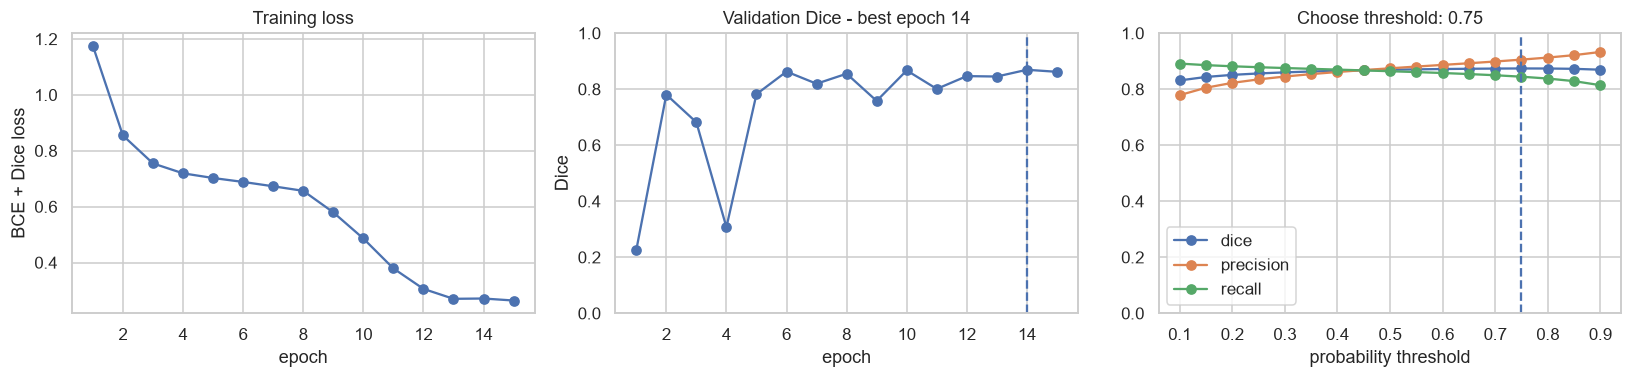

,micro_dice,micro_iou,micro_precision,micro_recall
method,,,,
Background,0.000,0.000,0.000,0.000
Otsu,0.044,0.023,0.023,0.668
Black-hat,0.519,0.350,0.892,0.366
Logistic Regression,0.552,0.381,0.400,0.891
U-Net,0.874,0.776,0.905,0.844


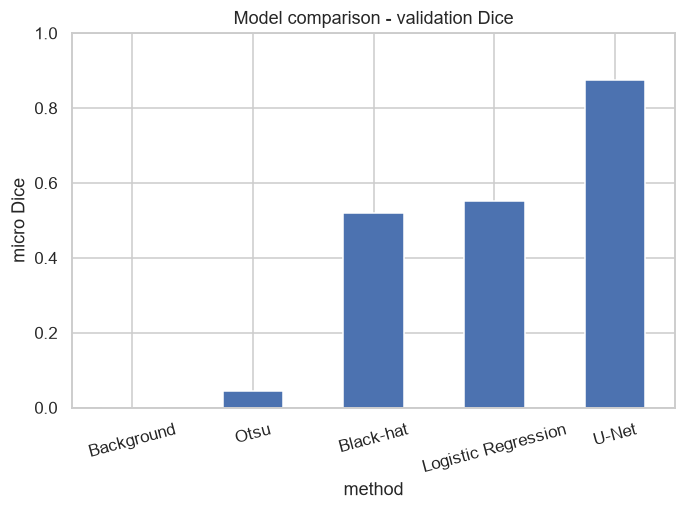

In [18]:
validation_crack_probability_maps = predict_unet_crack_probabilities(
    unet_model,
    validation_patch_images,
    show_progress=True,
)

candidate_probability_thresholds = np.arange(0.1, 0.95, 0.05)
probability_threshold_evaluation_table = pd.DataFrame([
    {
        "threshold": round(float(probability_threshold), 2),
        **calculate_segmentation_metrics(
            *calculate_pixel_confusion_counts(
                validation_crack_probability_maps > probability_threshold,
                validation_patch_masks,
            )[:3]
        ),
    }
    for probability_threshold in tqdm(
        candidate_probability_thresholds,
        desc="threshold sweep",
    )
])

BEST_CRACK_PROBABILITY_THRESHOLD = float(
    probability_threshold_evaluation_table.loc[
        probability_threshold_evaluation_table["dice"].idxmax(),
        "threshold",
    ]
)

training_summary_figure, training_summary_axes = plt.subplots(
    1,
    3,
    figsize=(15, 3.6),
)

training_summary_axes[0].plot(
    training_history_table["epoch"],
    training_history_table["loss"],
    marker="o",
)
training_summary_axes[0].set_title("Training loss")
training_summary_axes[0].set_xlabel("epoch")
training_summary_axes[0].set_ylabel("BCE + Dice loss")

training_summary_axes[1].plot(
    training_history_table["epoch"],
    training_history_table["val_dice"],
    marker="o",
)
training_summary_axes[1].axvline(best_validation_epoch, linestyle="--")
training_summary_axes[1].set_title(
    f"Validation Dice - best epoch {best_validation_epoch}"
)
training_summary_axes[1].set_xlabel("epoch")
training_summary_axes[1].set_ylabel("Dice")
training_summary_axes[1].set_ylim(0, 1)

for metric_name in ["dice", "precision", "recall"]:
    training_summary_axes[2].plot(
        probability_threshold_evaluation_table["threshold"],
        probability_threshold_evaluation_table[metric_name],
        marker="o",
        label=metric_name,
    )
training_summary_axes[2].axvline(
    BEST_CRACK_PROBABILITY_THRESHOLD,
    linestyle="--",
)
training_summary_axes[2].set_title(
    f"Choose threshold: {BEST_CRACK_PROBABILITY_THRESHOLD:.2f}"
)
training_summary_axes[2].set_xlabel("probability threshold")
training_summary_axes[2].set_ylim(0, 1)
training_summary_axes[2].legend()
plt.show()

unet_validation_metrics = evaluate_segmentation_predictions(
    (
        validation_crack_probability_maps[validation_patch_index]
        > BEST_CRACK_PROBABILITY_THRESHOLD,
        validation_patch_masks[validation_patch_index],
    )
    for validation_patch_index in range(len(validation_patch_masks))
)
unet_validation_metrics["method"] = "U-Net"
validation_model_results.append(unet_validation_metrics)

model_comparison_table = pd.DataFrame(validation_model_results).set_index(
    "method"
)

displayed_segmentation_metric_columns = [
    "micro_dice",
    "micro_iou",
    "micro_precision",
    "micro_recall",
]
display(
    model_comparison_table[
        displayed_segmentation_metric_columns
    ].style.format("{:.3f}")
)

model_comparison_table["micro_dice"].plot.bar(
    title="Model comparison - validation Dice",
    ylabel="micro Dice",
    ylim=(0, 1),
    rot=15,
)
plt.show()

model_comparison_table.to_csv(
    OUTPUT_DIRECTORY / "model_comparison.csv"
)


### 11.4 Model comparison

The table compares all methods on the same validation data using the same segmentation metrics.

- **Background** proves that pixel accuracy alone is misleading.
- **Otsu** is a naive thresholding baseline.
- **Black-hat** is a stronger hand-written image-processing baseline.
- **Logistic Regression** learns from hand-crafted pixel features.
- **U-Net** learns both features and spatial context directly from the RGB patches.

We still select the best epoch and the best probability threshold on the **validation** split, so the held-out test split remains untouched in this proposal.

---
## 12. Confusion matrices

Dice gives one summary number, but a confusion matrix explains **how** a model fails.

For segmentation, the entries are counted over **pixels**:

- **TN**: background predicted as background
- **FP**: background predicted as crack
- **FN**: crack predicted as background
- **TP**: crack predicted as crack

To make models comparable despite the strong class imbalance, the heatmaps below are **row-normalized**. Each row therefore sums to 100% and answers:

- for true background pixels: how many stayed background, and how many became false alarms?
- for true crack pixels: how many were found, and how many were missed?

confusion: Background:   0%|          | 0/1758 [00:00<?, ?it/s]

confusion: Otsu:   0%|          | 0/1758 [00:00<?, ?it/s]

confusion: Black-hat:   0%|          | 0/1758 [00:00<?, ?it/s]

confusion: Logistic Regression:   0%|          | 0/1758 [00:00<?, ?it/s]

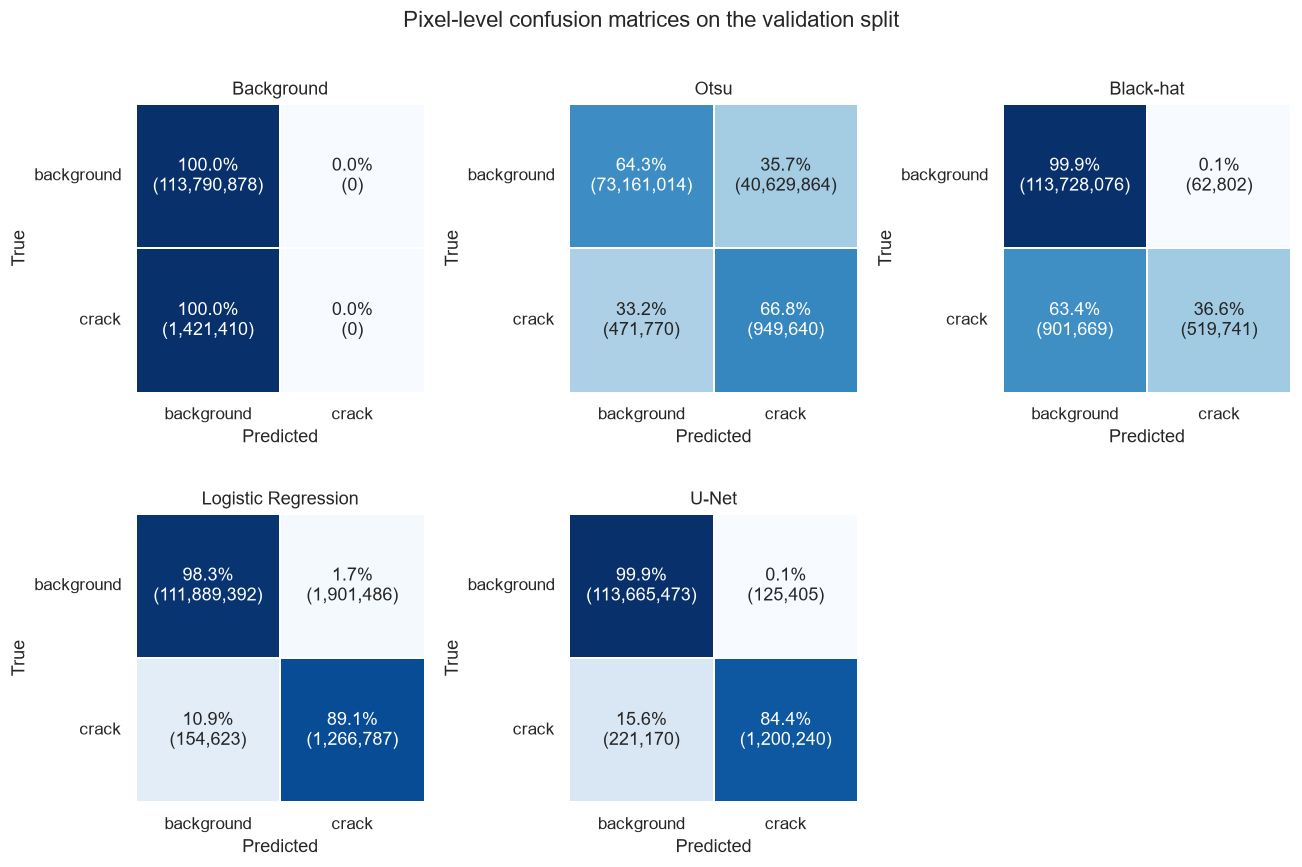

In [19]:
def aggregate_pixel_confusion_counts(prediction_pairs):
    """Add pixel-level confusion counts across all supplied mask pairs."""
    total_true_positive = 0
    total_false_positive = 0
    total_false_negative = 0
    total_true_negative = 0

    for predicted_mask, ground_truth_mask in prediction_pairs:
        (
            true_positive_count,
            false_positive_count,
            false_negative_count,
            true_negative_count,
        ) = calculate_pixel_confusion_counts(predicted_mask, ground_truth_mask)
        total_true_positive += true_positive_count
        total_false_positive += false_positive_count
        total_false_negative += false_negative_count
        total_true_negative += true_negative_count

    return {
        "tp": total_true_positive,
        "fp": total_false_positive,
        "fn": total_false_negative,
        "tn": total_true_negative,
    }


def plot_normalized_confusion_matrix(
    plot_axis,
    pixel_confusion_counts,
    method_title,
):
    """Plot a row-normalized pixel-level confusion matrix."""
    confusion_count_matrix = np.array([
        [pixel_confusion_counts["tn"], pixel_confusion_counts["fp"]],
        [pixel_confusion_counts["fn"], pixel_confusion_counts["tp"]],
    ], dtype=np.float64)

    row_normalized_confusion_matrix = (
        confusion_count_matrix
        / confusion_count_matrix.sum(axis=1, keepdims=True)
    )
    confusion_matrix_annotations = np.empty_like(
        row_normalized_confusion_matrix,
        dtype=object,
    )

    for true_class_index in range(2):
        for predicted_class_index in range(2):
            confusion_matrix_annotations[
                true_class_index,
                predicted_class_index,
            ] = (
                f"{100 * row_normalized_confusion_matrix[true_class_index, predicted_class_index]:.1f}%\n"
                f"({int(confusion_count_matrix[true_class_index, predicted_class_index]):,})"
            )

    sns.heatmap(
        row_normalized_confusion_matrix,
        annot=confusion_matrix_annotations,
        fmt="",
        cmap="Blues",
        cbar=False,
        vmin=0,
        vmax=1,
        ax=plot_axis,
        linewidths=1,
        linecolor="white",
        square=True,
    )
    plot_axis.set_title(method_title)
    plot_axis.set_xlabel("Predicted")
    plot_axis.set_ylabel("True")
    plot_axis.set_xticklabels(["background", "crack"], rotation=0)
    plot_axis.set_yticklabels(["background", "crack"], rotation=0)


confusion_counts_by_method = {}

confusion_counts_by_method["Background"] = aggregate_pixel_confusion_counts(
    (
        np.zeros_like(ground_truth_mask, dtype=bool),
        ground_truth_mask,
    )
    for _, ground_truth_mask in iterate_image_mask_patches_for_split(
        "val",
        progress_description="confusion: Background",
    )
)
confusion_counts_by_method["Otsu"] = aggregate_pixel_confusion_counts(
    (
        predict_crack_mask_with_otsu(rgb_image_patch),
        ground_truth_mask,
    )
    for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
        "val",
        progress_description="confusion: Otsu",
    )
)
confusion_counts_by_method["Black-hat"] = aggregate_pixel_confusion_counts(
    (
        predict_crack_mask_with_black_hat(rgb_image_patch),
        ground_truth_mask,
    )
    for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
        "val",
        progress_description="confusion: Black-hat",
    )
)
confusion_counts_by_method["Logistic Regression"] = aggregate_pixel_confusion_counts(
    (
        predict_logistic_regression_crack_probabilities(rgb_image_patch) > 0.5,
        ground_truth_mask,
    )
    for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
        "val",
        progress_description="confusion: Logistic Regression",
    )
)
confusion_counts_by_method["U-Net"] = aggregate_pixel_confusion_counts(
    (
        validation_crack_probability_maps[validation_patch_index]
        > BEST_CRACK_PROBABILITY_THRESHOLD,
        validation_patch_masks[validation_patch_index],
    )
    for validation_patch_index in range(len(validation_patch_masks))
)

confusion_matrix_figure, confusion_matrix_axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)
confusion_matrix_axes = confusion_matrix_axes.ravel()
displayed_method_order = [
    "Background",
    "Otsu",
    "Black-hat",
    "Logistic Regression",
    "U-Net",
]

for plot_axis, method_name in zip(
    confusion_matrix_axes,
    displayed_method_order,
):
    plot_normalized_confusion_matrix(
        plot_axis,
        confusion_counts_by_method[method_name],
        method_name,
    )

confusion_matrix_axes[-1].axis("off")
confusion_matrix_figure.suptitle(
    "Pixel-level confusion matrices on the validation split"
)
plt.show()


The models fail in different ways. **Black-hat** is highly conservative and produces few false alarms, but misses many crack pixels. **Logistic Regression** achieves high crack recall but at the cost of considerably more false positives. **U-Net** maintains high crack recall while sharply reducing false positives, resulting in the best balance between precision and recall and therefore the highest Dice score.

per-patch Dice:   0%|          | 0/1758 [00:00<?, ?it/s]

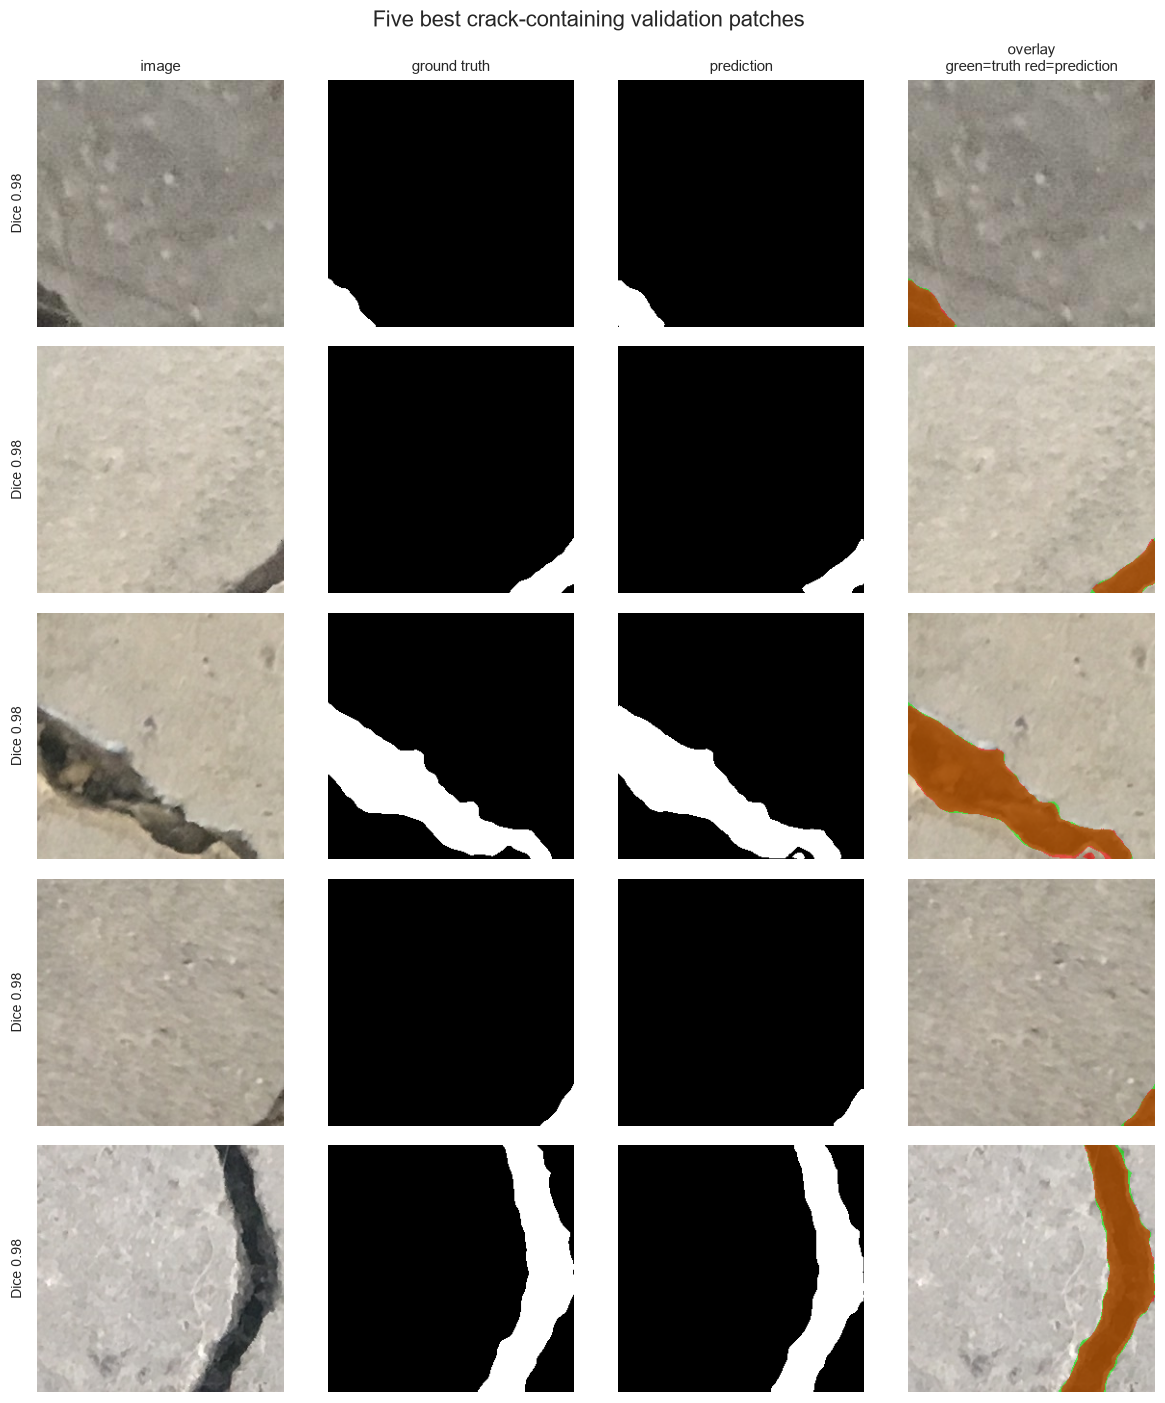

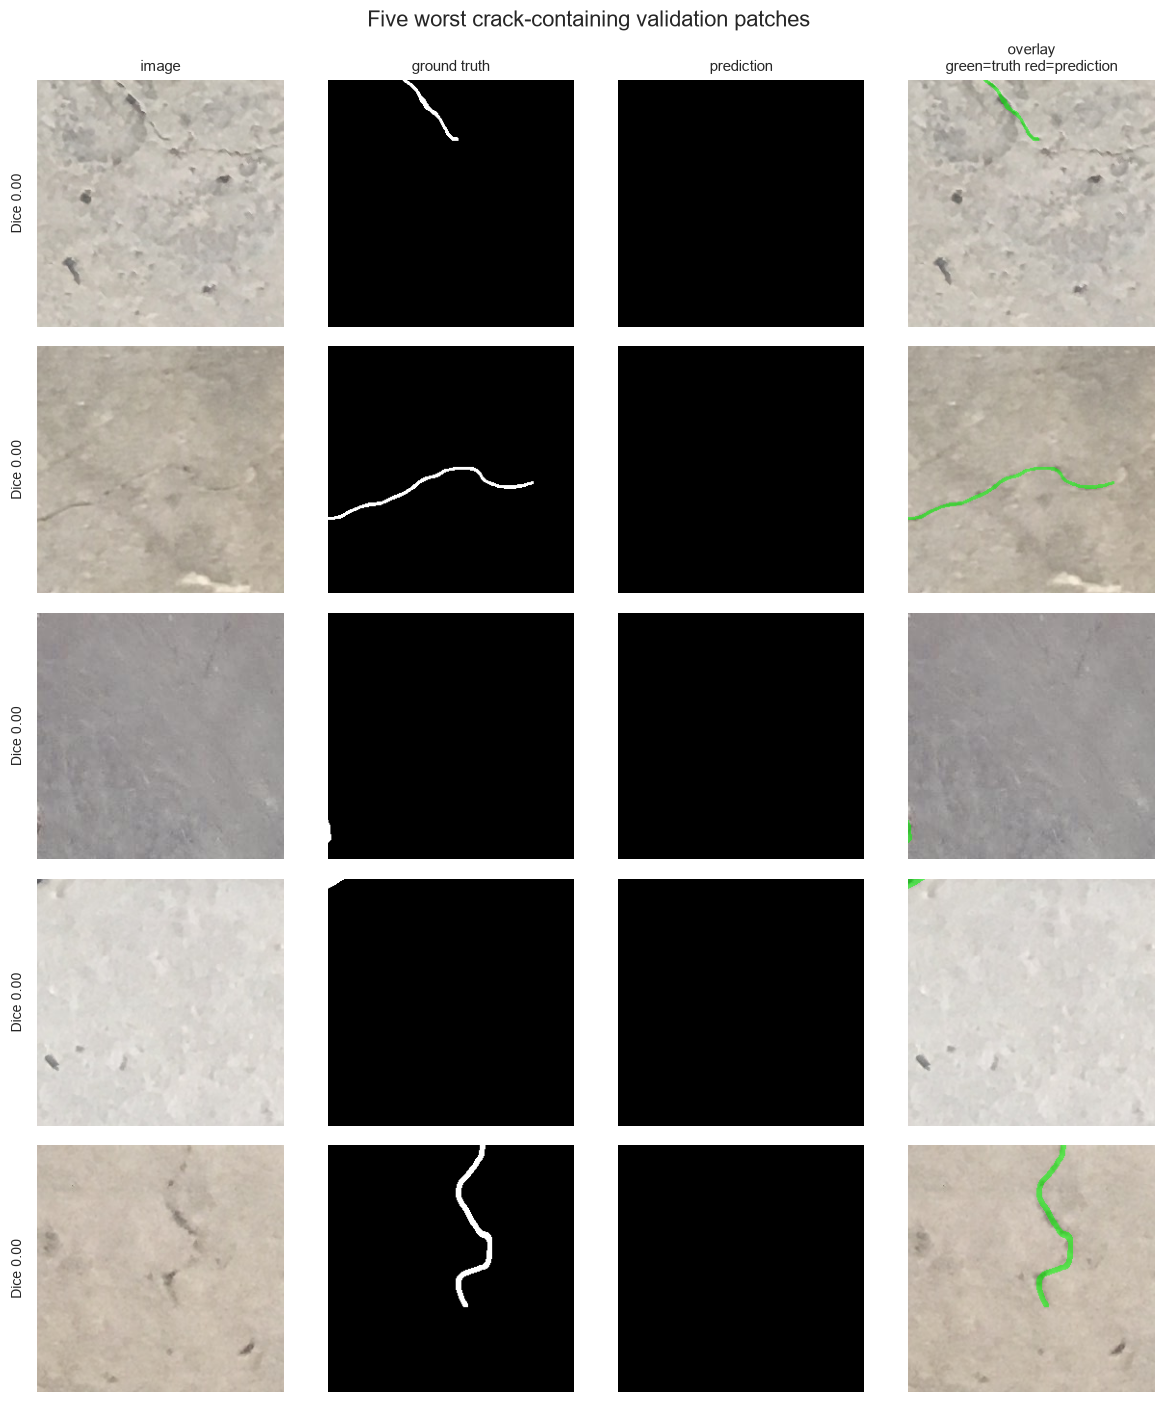

In [20]:
dice_score_per_validation_patch = np.array([
    calculate_segmentation_metrics(
        *calculate_pixel_confusion_counts(
            validation_crack_probability_maps[validation_patch_index]
            > BEST_CRACK_PROBABILITY_THRESHOLD,
            validation_patch_masks[validation_patch_index],
        )[:3]
    )["dice"]
    for validation_patch_index in tqdm(
        range(len(validation_patch_masks)),
        desc="per-patch Dice",
        leave=False,
    )
])

number_of_crack_pixels_per_validation_patch = (
    validation_patch_masks.sum(axis=(1, 2))
)

crack_containing_validation_patch_positions = np.flatnonzero(
    number_of_crack_pixels_per_validation_patch
    >= MINIMUM_CRACK_PIXELS_PER_PATCH
)
validation_patch_positions_ranked_by_dice = (
    crack_containing_validation_patch_positions[
        np.argsort(
            dice_score_per_validation_patch[
                crack_containing_validation_patch_positions
            ]
        )
    ]
)
best_validation_patch_positions = list(
    validation_patch_positions_ranked_by_dice[-5:][::-1]
)
worst_validation_patch_positions = list(
    validation_patch_positions_ranked_by_dice[:5]
)


def show_ranked_patch_examples(selected_patch_positions, figure_title):
    """Show original image, annotation, prediction and overlay for selected patches."""
    example_figure, example_axes = plt.subplots(
        len(selected_patch_positions),
        4,
        figsize=(11, 2.6 * len(selected_patch_positions)),
    )
    if len(selected_patch_positions) == 1:
        example_axes = np.array([example_axes])

    for example_row_index, validation_patch_position in enumerate(
        selected_patch_positions
    ):
        ground_truth_mask = validation_patch_masks[validation_patch_position]
        predicted_mask = (
            validation_crack_probability_maps[validation_patch_position]
            > BEST_CRACK_PROBABILITY_THRESHOLD
        )
        prediction_comparison_overlay = validation_patch_images[
            validation_patch_position
        ].copy()

        prediction_comparison_overlay[ground_truth_mask] = (
            0.45 * prediction_comparison_overlay[ground_truth_mask]
            + 0.55 * np.array([0, 255, 0])
        ).astype(np.uint8)
        prediction_comparison_overlay[predicted_mask] = (
            0.45 * prediction_comparison_overlay[predicted_mask]
            + 0.55 * np.array([255, 0, 0])
        ).astype(np.uint8)

        displayed_image_panels = [
            (
                validation_patch_images[validation_patch_position],
                None,
                "image",
            ),
            (ground_truth_mask, "gray", "ground truth"),
            (predicted_mask, "gray", "prediction"),
            (
                prediction_comparison_overlay,
                None,
                "overlay\ngreen=truth red=prediction",
            ),
        ]

        for panel_column_index, (
            panel_image,
            color_map_name,
            panel_title,
        ) in enumerate(displayed_image_panels):
            example_axes[example_row_index, panel_column_index].imshow(
                panel_image,
                cmap=color_map_name,
            )
            example_axes[example_row_index, panel_column_index].axis("off")
            if example_row_index == 0:
                example_axes[example_row_index, panel_column_index].set_title(
                    panel_title,
                    fontsize=10,
                )

        example_axes[example_row_index, 0].text(
            -0.08,
            0.5,
            f"Dice {dice_score_per_validation_patch[validation_patch_position]:.2f}",
            rotation=90,
            va="center",
            ha="center",
            transform=example_axes[example_row_index, 0].transAxes,
            fontsize=9,
        )

    example_figure.suptitle(figure_title)
    plt.show()


show_ranked_patch_examples(
    best_validation_patch_positions,
    "Five best crack-containing validation patches",
)
show_ranked_patch_examples(
    worst_validation_patch_positions,
    "Five worst crack-containing validation patches",
)

Visual examples complement the scores. To avoid treating annotation slivers as meaningful crack examples, this comparison uses the same definition introduced earlier: a crack-containing patch must contain at least **50 crack pixels**.

The **best** examples show what the U-Net handles well: clear crack structure with strong local contrast. The **worst** examples reveal more meaningful difficult cases, such as faint cracks, confusing background texture, differences between visible crack width and annotation width, or patch edges that cut the structure.

Using five good and five bad examples makes the failure analysis much easier to discuss than a single average score.

---
## 13. Explainability - what did Logistic Regression learn?

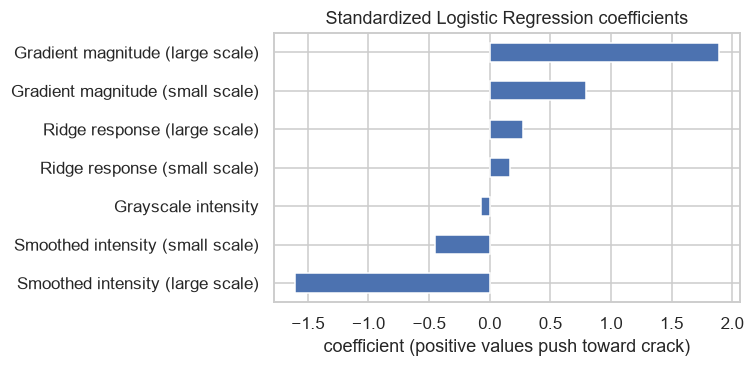

In [21]:
pixel_feature_display_names = {
    "grayscale_intensity": "Grayscale intensity",
    "smoothed_intensity_sigma_1": "Smoothed intensity (small scale)",
    "gradient_magnitude_sigma_1": "Gradient magnitude (small scale)",
    "ridge_response_sigma_1": "Ridge response (small scale)",
    "smoothed_intensity_sigma_4": "Smoothed intensity (large scale)",
    "gradient_magnitude_sigma_4": "Gradient magnitude (large scale)",
    "ridge_response_sigma_4": "Ridge response (large scale)",
}

standardized_logistic_regression_coefficients = pd.Series(
    pixel_logistic_regression_model.coef_[0],
    index=[
        pixel_feature_display_names[feature_name]
        for feature_name in PIXEL_FEATURE_NAMES
    ],
).sort_values()

figure, plot_axis = plt.subplots(figsize=(7, 3.5))
standardized_logistic_regression_coefficients.plot.barh(ax=plot_axis)
plot_axis.set_title("Standardized Logistic Regression coefficients")
plot_axis.set_xlabel("coefficient (positive values push toward crack)")
plt.show()


The Logistic Regression coefficients are consistent with the visual structure of cracks. **Gradient magnitude**, especially at the larger spatial scale, provides the strongest positive evidence for a crack, while **large-scale smoothed intensity** has a strong negative coefficient, meaning brighter local regions are less likely to be classified as crack. Ridge responses also contribute positively.

This is also a useful comparison with U-Net: Logistic Regression relies on a small **fixed** feature set, while U-Net learns its own features and uses a much larger neighbourhood around each pixel.

---
## 14. Tools

- **Python, pandas and NumPy** - data tables and numerical work
- **matplotlib / seaborn** - visualisation
- **OpenCV and scikit-image** - image processing and simple image features
- **scikit-learn** - PCA, K-Means and Logistic Regression
- **PyTorch** - U-Net training on the GPU
- **Pillow / ImageHash** - image loading, EXIF correction and duplicate checks

The main new topics beyond the workshop are semantic segmentation, U-Net, overlap-based loss and basic morphological image processing.

---
## 15. Limitations

**Data:** only 458 source photographs from one dataset, and every source photograph contains at least some crack. The JPEG masks also contain compression artifacts and may be slightly thicker than the visible cracks.

**Proposal scope:** expensive patch-level work uses a configurable subset of train and validation images rather than all 458. The U-Net is trained for a limited number of epochs as a preliminary experiment.

**Evaluation:** the validation split is used to choose the best epoch and prediction threshold, so validation performance is not an unbiased final score. The held-out test split is reserved for the final project.

---
## 16. Summary and next steps

The proposal covers the main stages of the segmentation project:

**quality control -> leakage-safe split -> 256 x 256 patches -> EDA -> simple baselines -> Logistic Regression -> U-Net -> validation analysis**

The proposal already answers useful questions: the masks need cleaning, most patches are empty, ordinary accuracy is misleading, and increasingly spatial models can be compared on the same Dice/IoU metrics.

### Final-project plan

- run the expensive stages on more or all source images;
- train the U-Net more fully and evaluate the frozen test split once;
- reconstruct predictions over whole images with overlapping patches;
- analyse the main false-positive and false-negative cases;
- compare performance across the visual clusters found in the EDA.